<a href="https://colab.research.google.com/github/VancuraFlow/MLDocs/blob/main/project1_RelayAI_student.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# [Project 1] LLM Routing
### RelayAI: Sending each question to the right AI model


**BMAI-SEP 2026, ETH Zurich** data from [`RZ412/EmbedLLM`](https://huggingface.co/datasets/RZ412/EmbedLLM)

---
Welcome to the team! You have just joined the AI platform group 🎉

RelayAI is an AI tutor which answers all sorts of techincal questions. Engineering students at ETH use it, medical students at UZH use it, high school students use it, and so do a few thousand people we did not expect. A large number of queries arrive every day, and they are nothing alike: one asks how to balance a redox equation, another asks about the standard of proof in a civil case, still another wants to solve a difficult trigonometry question.

Currently, RelayAI is running a few large LLM on its own GPUs to answer all these questions. Answers given out are of high quality, but as the number of users keeps growing we quickly hit a bottleneck. The existing models can no longer handle the growing traffic, but hosting additional big models gets too expensive. The engineering team also hypothesized that for easy questions, the big model is an overkill: A much smaller LLM can generate answers of almost the same quality at a fraction of the original cost with lower latency.


To address this challenge, the team shortlisted **70 open models** to be deployed on the company's hardware as the new RelayAI backend. Due to differences in training data and model sizes/architectures, each model can exhibit varying performance on different types of questions: one model may be particularly good at math, another at law, still another at chemistry. Your job is then to deploy an ***LLM router, which sends each incoming question to the "best" LLM for an answer***.


What should be considered "best" is of course a business question.
Bigger models typically give higher quality answers but incur higher inference costs. The team decided to model the cost-performance tradeoff with a parameter **λ≥0**: small λ prioritizes answer quality while large λ prioritizes cost saving.



In this project, you will implement the **router** as a ***neural network (NN)***. When a question comes in, your router predicts the answer quality of each model, and chooses the model with the best cost-performance tradeoff to answer it.

### The routing rule, written down

In this project, we make the (simplifying) assumption that each answer is either right or wrong. The quality of a model $m$ on a prompt $x$ is measured by its ***error rate***. If the model gives a correct (resp. incorrect) answer, its error rate would be 0 (resp. 1). The per-model error rate is then computed as its average error rate across a set of questions. We will refer to 1 minus error rate as ***accuracy***.

Given a prompt $x$, the router $r$ returns the model with the smallest cost adjusted error:

$$ r(x) \;=\; \arg\min_{m \in [M]} \Big[\, \gamma^{(m)}(x) \;+\; \lambda \cdot c^{(m)} \,\Big] $$

<center>

| symbol | meaning |
|---|---|
| $x$ | the incoming prompt (question) |
| $m \in [M]$ | one of the $M=70$ models in our catalog |
| $c^{(m)}$ | the cost of calling model $m$, known and fixed |
| $\lambda$ | business decision: high means "save cost", low means "maximize quality" |
| $\gamma^{(m)}(x)$ | the **(predicted) error rate** of model $m$ on prompt $x$, a number between 0 and 1 |
</center>

Here we have made another simplying assumption that the cost does not depend on the prompt. This is not true technically, but we will take this as the average inference cost across the dataset, which is a reasonable estimate.

Everything in this rule is already known except one term. The costs are on a price list, λ is a setting, and the arg min is one line of numpy. The only thing that has to be built is $\gamma$.

### Setup

In [ ]:
#@title Imports and Setup {display-mode: "form"}
import os, subprocess, shutil
from pathlib import Path
import numpy as np, pandas as pd, time
import torch, torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from IPython.display import HTML, display
from ipywidgets import widgets, interact, FloatSlider
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, LinearSegmentedColormap
from matplotlib.patches import Ellipse
import textwrap


OWNER, REPO = "eth-bmai-hs26", "w1-project-public"
REPO_DIR = Path(REPO)
DATA_DIR = "data"

if Path(DATA_DIR, "embeddings.npy").exists():
    print("data is already here, nothing to clone")
else:
    if REPO_DIR.exists():
        shutil.rmtree(REPO_DIR)
    url = f"https://github.com/{OWNER}/{REPO}.git"
    subprocess.run(["git", "clone", "--depth", "1", url, str(REPO_DIR)], check=True)
    shutil.copytree(REPO_DIR / "data", DATA_DIR, dirs_exist_ok=True)
    print("cloned")

SEED = 0
np.random.seed(SEED); torch.manual_seed(SEED)
RNG = np.random.default_rng(SEED)
DEVICE = "cpu" # The NNs in this project are small, so no need to use GPU.
print(f"libraries ready, device {DEVICE}")

data is already here, nothing to clone
libraries ready, device cpu


In [ ]:
#@title Visualization helpers {display-mode: "form"}
OKABE_ITO = ["#0072B2", "#D55E00", "#009E73", "#CC79A7",
             "#E69F00", "#56B4E9", "#F0E442", "#000000"]
TOL_MUTED = ["#332288", "#88CCEE", "#44AA99", "#117733", "#999933",
             "#DDCC77", "#CC6677", "#882255", "#AA4499", "#661100"]
CB = dict(blue="#0072B2", vermillion="#D55E00", green="#009E73", purple="#CC79A7",
          orange="#E69F00", sky="#56B4E9", indigo="#332288", grey="#BBBBBB", dark="#333333")
CB_CMAP = ListedColormap(OKABE_ITO)
plt.rcParams.update({"axes.prop_cycle": plt.cycler(color=OKABE_ITO), "figure.dpi": 110,
                     "axes.grid": True, "grid.alpha": .3,
                     "axes.spines.top": False, "axes.spines.right": False,
                     "legend.frameon": False})

_CARD_CSS = """
<style>
.p0{font-family:system-ui,-apple-system,Segoe UI,Roboto,sans-serif;margin:14px 0}
.p0-card{background:#fff;border:1px solid #ecedf2;border-radius:14px;padding:16px 18px;margin:12px 0}
.p0-t{font-size:14px;font-weight:700;color:#2f2f38;margin:0 0 2px 0}
.p0-s{font-size:12px;color:#767688;margin:0 0 12px 0}
.p0-g{width:100%;border-collapse:collapse;font-size:12.5px}
.p0-g td{padding:7px 8px;border-top:1px solid #f1f1f5;vertical-align:top}
.p0-g tr:first-child td{border-top:none}
.p0-f{font-family:ui-monospace,SFMono-Regular,Menlo,monospace;font-size:12px;font-weight:650;
      color:#2f2f38;white-space:nowrap;width:1%}
.p0-d{color:#4a4a58;line-height:1.5}
.p0-skip .p0-f,.p0-skip .p0-d{color:#a6a6b4}
.p0-chips{display:flex;flex-wrap:wrap;gap:7px}
.p0-chip{display:inline-flex;align-items:center;gap:7px;border-radius:999px;padding:5px 12px 5px 8px;
         font-size:12px;color:#2f2f38;background:#f6f6f9;border:1px solid #ecedf2}
.p0-dot{width:10px;height:10px;border-radius:50%;flex:0 0 auto}
.p0-n{font-variant-numeric:tabular-nums;color:#767688;font-size:11px}
</style>"""

def render_glossary(title, subtitle, rows):
    """A card listing the columns of a file: field name, then what it is.

    `rows` is a list of (field, description) or (field, description, "skip") when the
    column exists in the file but we will not use it.
    """
    h = [_CARD_CSS, f'<div class="p0"><div class="p0-card"><p class="p0-t">{title}</p>'
                    f'<p class="p0-s">{subtitle}</p><table class="p0-g">']
    for r in rows:
        field, desc = r[0], r[1]
        cls = ' class="p0-skip"' if len(r) > 2 else ""
        h.append(f'<tr{cls}><td class="p0-f">{field}</td><td class="p0-d">{desc}</td></tr>')
    h.append("</table></div></div>")
    display(HTML("".join(h)))

def render_chips(items):
    """A row of coloured pills: (label, colour, count)."""
    h = [_CARD_CSS, '<div class="p0"><div class="p0-chips">']
    for label, colour, n in items:
        h.append(f'<span class="p0-chip"><span class="p0-dot" style="background:{colour}"></span>'
                 f'{label}<span class="p0-n">{n:,}</span></span>')
    h.append("</div></div>")
    display(HTML("".join(h)))

_TONES = {
    "gray":   ("#f4f4f6", "#dcdce3", "#2f2f38"),
    "red":    ("#fdeceb", "#f0c2bd", "#9c3025"),
    "green":  ("#e7f6ee", "#b3dfc8", "#1c6b45"),
    "purple": ("#eeeafb", "#c9bcf0", "#4c2f92"),
    "blue":   ("#e9eefb", "#bcc9ef", "#2b4a91"),
}
_CSS = """
<style>
.rt{font-family:system-ui,-apple-system,Segoe UI,Roboto,sans-serif;margin:10px 0}
.rt-card{background:#fff;border:1px solid #ecedf2;border-radius:16px;padding:18px 20px;margin:14px 0}
.rt-h{display:flex;align-items:baseline;gap:10px;margin:0 0 16px}
.rt-n{font-size:16px;font-weight:800;color:#1b1b23}
.rt-s{font-size:12.5px;color:#8b8b9a}
.rt-grid{display:grid;grid-template-columns:1.35fr 26px 1.35fr 26px 1.35fr 26px auto;
         align-items:center;row-gap:6px}
.rt-box{border-radius:10px;padding:10px 12px;text-align:center;min-height:44px;
        display:flex;flex-direction:column;justify-content:center}
.rt-bt{font-size:13.5px;font-weight:700;line-height:1.25}
.rt-bd{font-size:10.5px;opacity:.72;margin-top:3px;line-height:1.3}
.rt-ar{text-align:center;color:#b9b9c6;font-size:15px}
.rt-dn{text-align:center;color:#b9b9c6;font-size:15px;height:26px;line-height:26px}
.rt-end{font-size:13px;color:#5a5a6b;font-weight:600;padding-left:4px}
.rt-note{margin-top:12px;border-radius:10px;padding:9px 12px;font-size:12px;text-align:center}
.rt-pl{background:linear-gradient(135deg,#f7f9ff,#fcf6ff);border:1px solid #edecff;
       border-radius:16px;padding:18px 16px}
.rt-plh{font-size:17px;font-weight:800;color:#3b2d6b;margin:0 0 14px}
.rt-plr{display:flex;align-items:flex-start;flex-wrap:wrap}
.rt-pls{flex:1 1 100px;min-width:100px;text-align:center;padding:0 2px}
.rt-plic{width:46px;height:46px;border-radius:50%;margin:0 auto 7px;display:flex;
         align-items:center;justify-content:center;font-size:20px;color:#fff;
         box-shadow:0 6px 14px rgba(102,126,234,.3)}
.rt-plt{font-weight:700;font-size:12px;color:#2c2350}
.rt-pld{font-size:10px;color:#8b86a6;margin-top:2px}
.rt-pla{display:flex;align-items:center;font-size:17px;color:#b9a9e6;flex:0 0 14px;height:46px}
.rt-tiles{display:flex;gap:10px;flex-wrap:wrap;margin:10px 0}
.rt-tile{flex:1 1 130px;border:1px solid #ecedf2;border-radius:12px;padding:12px 14px;background:#fff}
.rt-tv{font-size:20px;font-weight:800;color:#1b1b23}
.rt-tl{font-size:11px;color:#8b8b9a;margin-top:3px}
</style>
"""

def render_methods(specs):
    """Side by side view of routing pipelines. Node i of a lane sits in grid column 2i+1."""
    cards = ""
    for sp in specs:
        bg, br, fg = _TONES[sp.get("tone", "blue")]
        cells = ""
        for li, lane in enumerate(sp["lanes"]):
            if li > 0:
                col = 2 * sp.get("drop", 0) + 1
                cells += f'<div class="rt-dn" style="grid-column:{col}">&#8595;</div>'
            for i, (kind, t, d) in enumerate(lane):
                col = 2 * i + 1
                if kind == "end":
                    cells += f'<div class="rt-end" style="grid-column:{col}">{t}</div>'
                    continue
                k_bg, k_br, k_fg = _TONES["gray"] if kind == "in" else (bg, br, fg)
                cells += (f'<div class="rt-box" style="grid-column:{col};background:{k_bg};'
                          f'border:1px solid {k_br};color:{k_fg}">'
                          f'<div class="rt-bt">{t}</div>'
                          + (f'<div class="rt-bd">{d}</div>' if d else "") + "</div>")
                if i + 1 < len(lane):
                    cells += f'<div class="rt-ar" style="grid-column:{col + 1}">&#10230;</div>'
        note = ""
        if sp.get("note"):
            note = (f'<div class="rt-note" style="background:{bg};border:1px solid {br};'
                    f'color:{fg}">{sp["note"]}</div>')
        cards += (f'<div class="rt-card"><div class="rt-h"><span class="rt-n">{sp["n"]}. '
                  f'{sp["title"]}</span><span class="rt-s">{sp["subtitle"]}</span></div>'
                  f'<div class="rt-grid">{cells}</div>{note}</div>')
    display(HTML(_CSS + f'<div class="rt">{cards}</div>'))

def render_pipeline(title, emoji, steps):
    """Left to right step diagram: list of (icon, title, description)."""
    grad = ["#667eea", "#7573ee", "#8b6fe8", "#a36ddc", "#b96bcc", "#cc6abb", "#d96bad"]
    while len(grad) < len(steps):
        grad += grad
    blocks = ""
    for (ic, t, d), g in zip(steps, grad):
        blocks += (f'<div class="rt-pls"><div class="rt-plic" style="background:'
                   f'linear-gradient(135deg,{g},{g}cc)">{ic}</div>'
                   f'<div class="rt-plt">{t}</div><div class="rt-pld">{d}</div></div>'
                   '<div class="rt-pla">&#10230;</div>')
    blocks = blocks.rsplit('<div class="rt-pla">&#10230;</div>', 1)[0]
    display(HTML(_CSS + f'<div class="rt"><div class="rt-pl"><div class="rt-plh">{emoji} {title}'
                        f'</div><div class="rt-plr">{blocks}</div></div></div>'))

def render_tiles(pairs):
    """A row of headline numbers: list of (value, label)."""
    t = "".join(f'<div class="rt-tile"><div class="rt-tv">{v}</div>'
                f'<div class="rt-tl">{l}</div></div>' for v, l in pairs)
    display(HTML(_CSS + f'<div class="rt"><div class="rt-tiles">{t}</div></div>'))

def render_uniroute():
    """Simplified version of the UniRoute figure: two inputs meet in a dot product."""
    bg, br, fg = _TONES["purple"]; gb, gr, gf = _TONES["gray"]
    box = lambda t, s, c=(bg, br, fg): (f'<div class="rt-box" style="flex:1;background:{c[0]};'
        f'border:1px solid {c[1]};color:{c[2]}"><div class="rt-bt">{t}</div>'
        + (f'<div class="rt-bd">{s}</div>' if s else "") + "</div>")
    arr = '<div class="rt-pla" style="flex:0 0 22px;justify-content:center">&#10230;</div>'
    row = lambda *b: '<div style="display:flex;align-items:center;gap:6px;margin:6px 0">' + arr.join(b) + "</div>"
    top = row(box("question x", "the 384 number fingerprint", (gb, gr, gf)),
              box("Question network &#934;(x;&#952;)", "the neural net you train"),
              box("cluster membership", "e.g. [0.7, 0.3, 0.0]"))
    bot = row(box("model h on validation", "which questions it gets wrong", (gb, gr, gf)),
              box("Per cluster error &#936;(h)", "measured, not trained"),
              box("error per cluster", "e.g. [0.6, 0.2, 0.4]"))
    tail = row(box("dot product &#934;(x;&#952;) &#183; &#936;(h)", "one predicted error, gamma"),
               box("+ lambda &#183; cost", "the client's dial"),
               box("argmin over models", "call exactly one model", (_TONES["green"])))
    html = (_CSS + '<div class="rt"><div class="rt-card">'
            '<div class="rt-h"><span class="rt-n">UniRoute in one picture</span>'
            '<span class="rt-s">two inputs meet in a dot product, then the usual rule</span></div>'
            + top + bot
            + '<div style="text-align:center;color:#b9b9c6;font-size:15px;margin:2px">&#8595;</div>'
            + tail + "</div></div>")
    display(HTML(html))

# ----------------------------------------------------------------- reading a prompt
# Benchmark prompts are wrapped in harness scaffolding: mmlu opens every prompt of a subject with
# the same header, truthfulqa puts a fixed six pair few-shot primer in front of the real question.
# Reading a prompt from the front therefore makes whole families of them look identical, so the
# question is taken from the LAST block instead. Same rule build_dataset.py groups prompts with.
import re as _re
from html import escape as _esc

_MMLU_HDR = _re.compile(r"^the following are multiple choice questions \(with answers\) about ([^\n]*)\n", _re.I)
_LEADIN   = _re.compile(r"^\s*(what is the correct answer to this question\s*:|question\s*:|q\s*:)\s*", _re.I)
_CUT      = _re.compile(r"\n\s*(choices\s*:|answer\s*:|a\s*:|let'?s think step by step)", _re.I)
_TAIL     = _re.compile(r"(let'?s think step by step\s*:?\s*|answer\s*:\s*|choices\s*:\s*)$", _re.I)
_PRIMER   = _re.compile(r"\n\s*A:\s*\S")            # an ANSWERED Q/A pair, i.e. a worked example
_OPTS     = _re.compile(r"\n\s*([A-D])\.\s*(.+?)(?=\n\s*[A-D]\.|\Z)", _re.S)
_MIN_STEM = 40

def _squash(t):
    return _re.sub(r"\s+", " ", str(t)).strip()

def question_of(text):
    """The question a prompt actually asks, with the harness scaffolding stripped."""
    raw = str(text)
    stripped = _MMLU_HDR.sub("", raw.lstrip())
    whole = _squash(_TAIL.sub("", _re.split(r"\n\s*[A-D]\.\s", stripped)[0]))
    body = stripped
    for marker in ("\nQuestion:", "\nQ:"):
        i = body.rfind(marker)
        if i != -1:
            body = body[i + len(marker):]
    body = _CUT.split(_LEADIN.sub("", body), maxsplit=1)[0]
    stem = _squash(_TAIL.sub("", _re.split(r"\n\s*[A-D]\.\s", body)[0]))
    # gsm8k and asdiv state the numbers in a passage and close with a short "Question:" line, so a
    # stem that short has thrown the context away. Those carry no primer, so the body is safe to
    # keep. A primer never is: it is identical across every prompt of the benchmark.
    if len(stem) < _MIN_STEM and len(_PRIMER.findall(raw)) < 2:
        return whole
    return stem or whole

def options_of(text):
    """The A to D answer options, when the prompt is multiple choice."""
    out = [(k, _squash(_TAIL.sub("", _squash(v)))) for k, v in _OPTS.findall("\n" + str(text).strip())]
    return [(k, v) for k, v in out if v]

def subject_of(text):
    """The mmlu subject a prompt announces, if it announces one."""
    m = _MMLU_HDR.match(str(text).lstrip())
    return m.group(1).strip(" .") if m else None

def shots_of(text):
    """How many worked examples sit in front of the real question."""
    return len(_PRIMER.findall(str(text)))

def prompt_row(idx, row, cap=300):
    """One prompt, unpacked into the fields the deck renders."""
    q = question_of(row["prompt"])
    return dict(id=int(idx), topic=row["category"], subject=subject_of(row["prompt"]),
                shots=shots_of(row["prompt"]), options=options_of(row["prompt"]),
                question=q if len(q) <= cap else q[:cap].rsplit(" ", 1)[0] + " ...")

# ----------------------------------------------------------------- the neon deck
_NX = """
<style>
.nx{--bg:#0b1020;--ln:#22305a;--cy:#22d3ee;--vi:#a78bfa;--mg:#f472b6;--ok:#34d399;
    --tx:#e8ecfb;--dim:#8ea0c8;font-family:system-ui,-apple-system,Segoe UI,Roboto,sans-serif;margin:12px 0}
.nx-wrap{background:radial-gradient(1200px 320px at 12% -10%,#1c2a55 0%,transparent 60%),
    linear-gradient(160deg,var(--bg) 0%,#080c18 100%);border:1px solid var(--ln);border-radius:18px;
    padding:18px 18px 14px;color:var(--tx);box-shadow:0 18px 40px -22px rgba(0,0,0,.9)}
.nx-hd{display:flex;align-items:baseline;gap:10px;margin:0 0 14px;flex-wrap:wrap}
.nx-ti{font-size:15px;font-weight:800;background:linear-gradient(90deg,var(--cy),var(--vi) 60%,var(--mg));
    -webkit-background-clip:text;background-clip:text;color:transparent}
.nx-sub{font-size:11.5px;color:var(--dim)}
.nx-mono{font-family:ui-monospace,SFMono-Regular,Menlo,monospace}
.nx-grid{display:grid;gap:10px}
.nx-card{position:relative;background:linear-gradient(180deg,rgba(34,211,238,.05),rgba(167,139,250,.04));
    border:1px solid var(--ln);border-radius:13px;padding:11px 13px 11px 15px;overflow:hidden}
.nx-card::before{content:"";position:absolute;left:0;top:0;bottom:0;width:3px;
    background:linear-gradient(180deg,var(--cy),var(--vi))}
.nx-row{display:flex;align-items:center;gap:8px;flex-wrap:wrap;margin-bottom:5px}
.nx-id{font-size:10px;color:var(--dim);letter-spacing:.6px}
.nx-chip{font-size:10px;font-weight:700;padding:2px 8px;border-radius:999px;
    border:1px solid rgba(34,211,238,.35);color:var(--cy);background:rgba(34,211,238,.09)}
.nx-chip.v{border-color:rgba(167,139,250,.4);color:var(--vi);background:rgba(167,139,250,.1)}
.nx-chip.m{border-color:rgba(244,114,182,.4);color:var(--mg);background:rgba(244,114,182,.1)}
.nx-q{font-size:13px;line-height:1.5}
.nx-opts{display:flex;gap:6px;flex-wrap:wrap;margin-top:8px}
.nx-opt{font-size:10.5px;color:var(--dim);border:1px solid var(--ln);border-radius:8px;
    padding:3px 8px;background:rgba(255,255,255,.02)}
.nx-opt b{color:var(--cy);font-weight:700;margin-right:4px}
.nx-cl{display:grid;grid-template-columns:auto 1fr;gap:11px;align-items:start}
.nx-av{width:40px;height:40px;border-radius:12px;display:flex;align-items:center;justify-content:center;
    font-size:20px;background:linear-gradient(135deg,rgba(34,211,238,.18),rgba(167,139,250,.18));
    border:1px solid var(--ln)}
.nx-nm{font-size:13px;font-weight:800}
.nx-bl{font-size:10.5px;color:var(--dim)}
.nx-say{margin-top:7px;font-size:12px;line-height:1.45;color:#cfd8f5;font-style:italic;
    border-left:2px solid rgba(167,139,250,.45);padding-left:9px}
.nx-foot{margin-top:11px;font-size:10.5px;color:var(--dim);text-align:right}
.nx-sc{display:grid;grid-template-columns:minmax(210px,1fr) 34px minmax(190px,.85fr) 34px minmax(230px,1.15fr);
    align-items:center}
.nx-ar{display:flex;align-items:center;justify-content:center;font-size:20px;color:#4b5f96}
.nx-pan{background:linear-gradient(180deg,rgba(34,211,238,.06),rgba(167,139,250,.05));
    border:1px solid var(--ln);border-radius:14px;padding:13px 14px;height:100%;
    display:flex;flex-direction:column;justify-content:center}
.nx-lab{font-size:9.5px;letter-spacing:1.3px;text-transform:uppercase;color:#6f83b5;margin-bottom:8px}
.nx-bub{background:rgba(255,255,255,.045);border:1px solid var(--ln);border-radius:12px;
    padding:9px 11px;font-size:12px;line-height:1.45;color:#dbe3fb}
.nx-core{text-align:center;border:1px solid rgba(167,139,250,.45);
    background:radial-gradient(120px 70px at 50% 30%,rgba(167,139,250,.22),transparent 70%)}
.nx-frm{font-size:13.5px;font-weight:800;color:#e6ddff}
.nx-frm2{font-size:11px;color:var(--dim);margin-top:5px}
.nx-mods{display:flex;flex-direction:column;gap:5px}
.nx-mod{display:grid;grid-template-columns:1fr auto;gap:8px;align-items:center;border:1px solid var(--ln);
    border-radius:9px;padding:5px 9px;font-size:11px;color:var(--dim);background:rgba(255,255,255,.02)}
.nx-mod.win{border-color:rgba(52,211,153,.6);color:#eafff6;
    background:linear-gradient(90deg,rgba(52,211,153,.2),rgba(34,211,238,.08))}
.nx-note{margin-top:12px;font-size:11px;color:var(--dim);text-align:center}
</style>
"""

def _nx_show(title, subtitle, body, foot):
    display(HTML(_NX + f'<div class="nx"><div class="nx-wrap"><div class="nx-hd">'
                 f'<span class="nx-ti">{_esc(title)}</span>'
                 f'<span class="nx-sub">{_esc(subtitle)}</span></div>{body}'
                 f'<div class="nx-foot">{_esc(foot)}</div></div></div>'))

def render_routing_scene(client, question, candidates, lam, title="One question, end to end",
                         subtitle="", note=""):
    """Client asks, router scores, one model is called. candidates are best first."""
    mods = ""
    for c in candidates:
        cls = "nx-mod win" if c.get("win") else "nx-mod"
        mark = "&#9679; called" if c.get("win") else "&#9675;"
        mods += (f'<div class="{cls}"><span><b>{_esc(c["name"])}</b></span>'
                 f'<span class="nx-mono">{c["score"]:.3f} &nbsp;{mark}</span></div>')
    left = (f'<div class="nx-pan"><div class="nx-lab">the client</div>'
            f'<div style="display:flex;align-items:center;gap:9px;margin-bottom:9px">'
            f'<div class="nx-av">{client["emoji"]}</div><div>'
            f'<div class="nx-nm">{_esc(client["name"])}</div>'
            f'<div class="nx-bl">{_esc(client["blurb"])}</div></div></div>'
            f'<div class="nx-bub">&ldquo;{_esc(question)}&rdquo;</div></div>')
    core = (f'<div class="nx-pan nx-core"><div class="nx-lab">the router</div>'
            f'<div class="nx-frm">&#947; = &#934;(x;&#952;) &#183; &#936;(h)</div>'
            f'<div class="nx-frm2">then + &#955; &#183; cost, &#955; = {lam:g}</div>'
            f'<div class="nx-frm2">then argmin over the pool</div></div>')
    right = (f'<div class="nx-pan"><div class="nx-lab">the pool</div>'
             f'<div class="nx-mods">{mods}</div></div>')
    arrow = '<div class="nx-ar"><span>&#10230;</span></div>'
    body = f'<div class="nx-sc">{left}{arrow}{core}{arrow}{right}</div>'
    if note:
        body += f'<div class="nx-note">{_esc(note)}</div>'
    _nx_show(title, subtitle, body, "score = gamma + lambda x cost, smaller is better")

# ----------------------------------------------------------------- topic champions chart
# Validated categorical palette, assigned in fixed slot order and keyed to the model, never to rank.
NX_PAL = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
_INK, _INK2, _GRID = "#0b0b0b", "#52514e", "#e6e6e3"

def topic_champions(prompts_, models_, L_, X_te_, pool_, cost_, short=lambda s: s):
    """Per topic, the most accurate model in the pool, measured on the held out prompts."""
    cats_ = prompts_.loc[X_te_, "category"].to_numpy()
    rows = []
    for c in sorted(pd.unique(cats_)):
        idx = X_te_[cats_ == c]
        acc = 1 - np.nanmean(L_[np.ix_(idx, pool_)], axis=0)
        j = int(pool_[int(np.argmax(acc))])
        rows.append(dict(topic=c, model=j, name=short(models_.loc[j, "model_name"]),
                         accuracy=float(np.max(acc)), cost=float(cost_[j]), n=len(idx)))
    return pd.DataFrame(rows).sort_values("accuracy", ascending=False).reset_index(drop=True)

def plot_champions(df, cost_, models_, pool_, short=lambda s: s):
    """Two panels on one topic axis: how good the winner is, and what it charges."""
    order = list(dict.fromkeys(df["name"]))
    colour = {n: NX_PAL[i % len(NX_PAL)] for i, n in enumerate(order)}
    y = np.arange(len(df))[::-1]
    fig, (axa, axc) = plt.subplots(1, 2, figsize=(13.4, 5.8), sharey=True,
                                   gridspec_kw=dict(width_ratios=[2.3, 1], wspace=.14))
    for ax in (axa, axc):
        ax.set_facecolor("#fcfcfb")
        for sp in ("top", "right", "left"):
            ax.spines[sp].set_visible(False)
        ax.spines["bottom"].set_color(_GRID)
        ax.xaxis.grid(True, color=_GRID, lw=.8); ax.set_axisbelow(True)
        ax.tick_params(colors=_INK2, labelsize=9, length=0)
    axa.barh(y, df["accuracy"], height=.62, color=[colour[n] for n in df["name"]])
    for yi, (a, n) in enumerate(zip(df["accuracy"], df["name"])):
        axa.text(a + .008, y[yi], f"{a:.0%}", va="center", ha="left", fontsize=9.5,
                 color=_INK, fontweight="bold")
        if a > .34:
            axa.text(.012, y[yi], n, va="center", ha="left", fontsize=9,
                     color="#ffffff", fontweight="bold")
        else:
            axa.text(a + .062, y[yi], n, va="center", ha="left", fontsize=9, color=_INK2)
    axa.set_xlim(0, 1.0); axa.set_xticks(np.arange(0, 1.01, .25))
    axa.set_xticklabels([f"{v:.0%}" for v in np.arange(0, 1.01, .25)])
    axa.set_yticks(y); axa.set_yticklabels(df["topic"], fontsize=9.5, color=_INK)
    axa.set_xlabel("accuracy of the best model on that topic", fontsize=9.5, color=_INK2)
    axc.barh(y, df["cost"], height=.62, color=[colour[n] for n in df["name"]])
    for yi, c_ in enumerate(df["cost"]):
        axc.text(c_ - .035, y[yi], f"{c_:.2f}", va="center", ha="right", fontsize=9.5,
                 color="#ffffff", fontweight="bold")
    dear = int(pool_[int(np.argmax(cost_[pool_]))])
    axc.set_xlim(0, 1.12); axc.set_xticks([0, .5, 1.0])
    axc.axvline(cost_[dear], color="#9a9a94", lw=1.1, ls=(0, (4, 3)), zorder=0)
    axc.text(cost_[dear] + .02, y[0] + .55,
             f"priciest in the pool: {short(models_.loc[dear, 'model_name'])} at {cost_[dear]:.2f}",
             fontsize=8.5, color=_INK2, ha="right", va="bottom")
    axc.set_xlabel("what that winner charges  (0 cheapest, 1 priciest)", fontsize=9.5, color=_INK2)
    handles = [plt.Rectangle((0, 0), 1, 1, color=colour[n]) for n in order]
    fig.legend(handles, order, loc="upper left", bbox_to_anchor=(.208, .945),
               ncol=min(len(order), 4), frameon=False, fontsize=9.5, handlelength=.9,
               handleheight=.9, columnspacing=1.5)
    fig.text(.208, .965, "Who to call for what: the best deployed model per topic, and its price",
             ha="left", va="bottom", fontsize=13.5, fontweight="bold", color=_INK)
    fig.subplots_adjust(left=.208, right=.985, top=.855, bottom=.105)
    plt.show()

print("helpers ready")

In [ ]:
# @title What the router does with one incoming question {display-mode: "form"}
render_pipeline("What the router does with one incoming question", "\U0001F9ED", [
    ("\u2709\uFE0F", "Question arrives", "a student asks something"),
    ("\U0001F9EE", "Turn it into numbers", "ϕ(x), a list of 384 numbers"),
    ("\U0001F52E", "Predict error", "γ⁽ᵐ⁾(x) for every model in the pool"),
    ("\u2696\uFE0F", "Add the cost", "γ⁽ᵐ⁾(x) + λ*c⁽ᵐ⁾"),
    ("\U0001F3AF", "Take the smallest", "exactly one model is called"),
])

# Part 0: Loading Data

Before building anything in AI, we need to know what we are working with.

To predict an error, the router has to learn from examples. For this project, we use a processed version of the publicly available [`RZ412/EmbedLLM`](https://huggingface.co/datasets/RZ412/EmbedLLM) dataset. In reality, you would most likely need to construct your own dataset of this form which caters to your specific needs.



Our dataset is **labelled**: each row is a prompt, and for every model we recorded whether it answered that prompt correctly. Training on this lets the router generalize to prompts it has never seen.

The dataset has four pieces:

| file | what it holds | why we need it |
|---|---|---|
| `prompts.csv.gz` | prompt id, text, topic category, train/val/test split | the questions, and which split each belongs to |
| `models.csv` | model name, size, cost, train/test pool | our catalog of models and their costs |
| `errors.npy` | a table of error rates, one row per prompt, one column per model | the labels the router learns from |
| `embeddings.npy` | the embedding $\phi(x)$, 384 numbers per prompt | the numeric form of each question a network can read |

### 1. `prompts.csv.gz`, the questions 📥

This is the input side. Every question that reaches RelayAI is one row here, and in the routing rule
above, a row of this file is the $x$.

In [ ]:
#@title Load the questions {display-mode: "form"}
prompts = pd.read_csv(f"{DATA_DIR}/prompts.csv.gz").drop(columns='category_raw')
print(f"{len(prompts):,} questions in total, which is how much labelled data we work with")
print("First three rows:")
prompts.head(3)

35,673 questions in total, which is how much labelled data we work with
First three rows:


,prompt_id,category,split,prompt
0,0,Graduate-level science (GPQA),test,"Question: A large gene has dozens of exons, of..."
1,1,Graduate-level science (GPQA),train,Question: Two quantum states with energies E1 ...
2,2,Graduate-level science (GPQA),train,Question: trans-cinnamaldehyde was treated wit...


In [ ]:
#@title What each column is {display-mode: "form"}
render_glossary(
    "prompts.csv.gz",
    f"{len(prompts):,} rows, one question per row",
    [("prompt_id", "The identifier of this data sample. Read it, do not compute with it. "
                   "What indexes everything numeric in this notebook is the <b>row position</b>, "
                   "not this number."),
     ("prompt", "The question itself, as text. This is what the client asked. "
                "We symbolise it with <b>x</b>."),
     ("category", f"One of {prompts['category'].nunique()} topics the question belongs to. "
                  "We colour almost everything by this."),
     ("split", "train, val or test. <b>This was decided for you.</b> So for every data sample you "
               "know whether it belongs to the training, validation or test split.")])

prompt_id,"The identifier of this data sample. Read it, do not compute with it. What indexes everything numeric in this notebook is the row position, not this number."
prompt,"The question itself, as text. This is what the client asked. We symbolise it with x."
category,One of 11 topics the question belongs to. We colour almost everything by this.
split,"train, val or test. This was decided for you. So for every data sample you know whether it belongs to the training, validation or test split."


In [ ]:
#@title The topics {display-mode: "form"}
categories = sorted(prompts["category"].unique())
TOPICS_ALL  = list(prompts["category"].value_counts().index)      # biggest first, fixed order
TOPIC_COLOR = {t: (TOL_MUTED[i] if i < len(TOL_MUTED) else CB["grey"])
               for i, t in enumerate(TOPICS_ALL)}
def tcol(t):
    """The fixed colour of one topic, the same in every plot from here on."""
    return TOPIC_COLOR.get(t, CB["grey"])

print(f"{len(categories)} distinct topics:")
render_chips([(t, tcol(t), int((prompts["category"] == t).sum())) for t in TOPICS_ALL])

11 distinct topics:


In [ ]:
#@title The splits, already decided for us by the dataset creators
X_tr  = prompts.index[prompts["split"] == "train"].to_numpy()
X_val = prompts.index[prompts["split"] == "val"].to_numpy()
X_te  = prompts.index[prompts["split"] == "test"].to_numpy()

print("=== Train/val/test split of the data ===")
for name, idx in [("train", X_tr), ("val", X_val), ("test", X_te)]:
    print(f"{name:>5} : {len(idx):>6,} questions  ({len(idx)/len(prompts):.0%})")

=== Train/val/test split of the data ===
train : 21,415 questions  (60%)
  val :  3,567 questions  (10%)
 test : 10,691 questions  (30%)


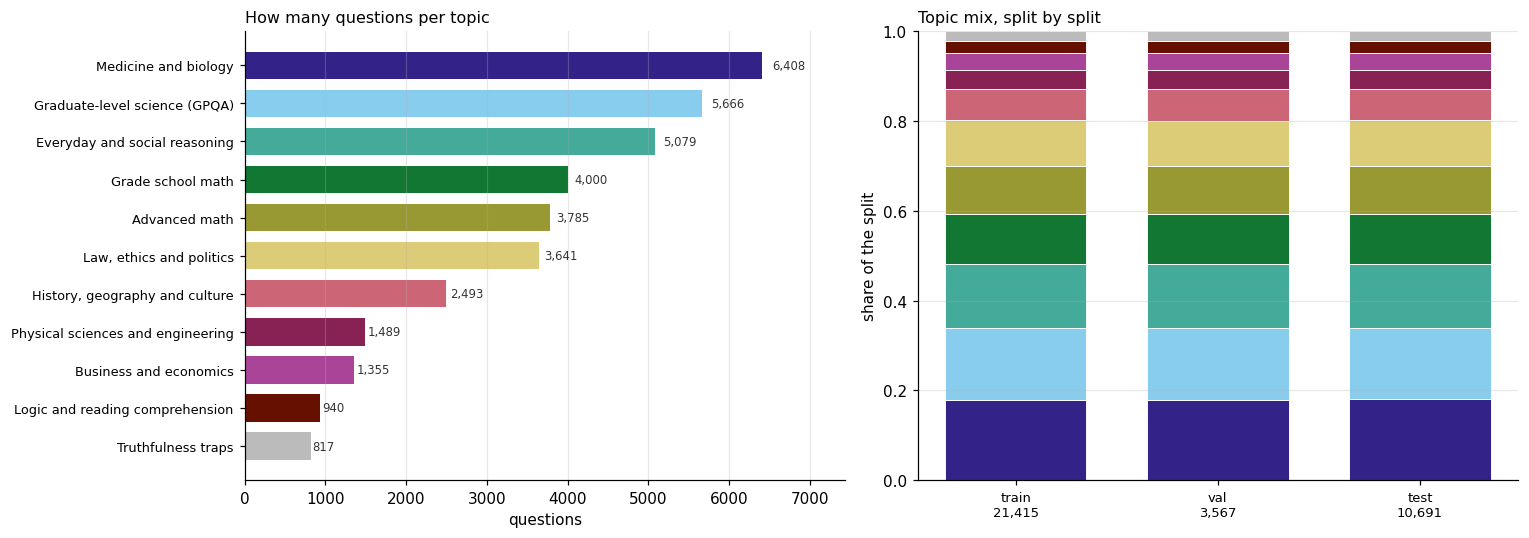

In [ ]:
#@title Some basic stats about the questions {display-mode: "form"}
_len = prompts["prompt"].str.len().to_numpy()
_top = prompts["category"].to_numpy()
_spl = prompts["split"].to_numpy()

fig, ax = plt.subplots(1, 2, figsize=(14.0, 5.0))

# --- how many questions per topic ---------------------------------------------------
_counts = prompts["category"].value_counts().loc[TOPICS_ALL[::-1]]
ax[0].barh(range(len(_counts)), _counts.to_numpy(),
           color=[tcol(t) for t in _counts.index], height=.72)
ax[0].set_yticks(range(len(_counts)))
ax[0].set_yticklabels([t[:34] for t in _counts.index], fontsize=8.4)
for i, v in enumerate(_counts.to_numpy()):
    ax[0].text(v * 1.02, i, f"{v:,}", va="center", fontsize=7.6, color=CB["dark"])
ax[0].set_xlim(0, _counts.max() * 1.16)
ax[0].set_xlabel("questions")
ax[0].set_title("How many questions per topic", fontsize=10.5, loc="left")
ax[0].grid(axis="y", visible=False)

# --- is the topic mix the same in all three splits? ---------------------------------
_mix = (pd.crosstab(_spl, _top, normalize="index")
          .reindex(index=["train", "val", "test"], columns=TOPICS_ALL))
_bottom = np.zeros(3)
for t in TOPICS_ALL:
    v = _mix[t].to_numpy()
    ax[1].bar(range(3), v, bottom=_bottom, color=tcol(t), width=.7,
              edgecolor="white", lw=.6, label=t)
    _bottom += v
ax[1].set_xticks(range(3))
ax[1].set_xticklabels([f"{s}\n{(_spl == s).sum():,}" for s in ["train", "val", "test"]],
                      fontsize=8.6)
ax[1].set_ylim(0, 1); ax[1].set_ylabel("share of the split")
ax[1].set_title("Topic mix, split by split", fontsize=10.5, loc="left")
ax[1].grid(axis="x", visible=False)
plt.tight_layout()
plt.show()

As you can see, the porportion of each class is balanced across each split.

### 2. `models.csv`, the catalog 🏷️

Every row is a model we could call, and the router's whole job is picking one of them per question.

In [ ]:
#@title Load the catalog {display-mode: "form"}
models = pd.read_csv(f"{DATA_DIR}/models.csv").drop(columns=['size_parsed'])
cost   = models["cost"].to_numpy(np.float32)

print(f"{models['model_name'].nunique()} distinct models in the catalog")
print("First three rows:")
models.head(3)

112 distinct models in the catalog
First three rows:


,model_id,model_name,family,params_B,cost,pool,error_rate
0,0,Qwen__Qwen1.5-7B-Chat,qwen,7.0,0.531017,train,0.554789
1,1,ConvexAI__Luminex-34B-v0.1,convexai,34.0,0.849028,train,0.453536
2,2,lmsys__vicuna-13b-v1.5,vicuna,13.0,0.655579,train,0.590503


In [ ]:
#@title What each column is {display-mode: "form"}
render_glossary(
    "models.csv",
    f"{len(models)} rows, one model per row",
    [("model_id", "The identifier of the model. As with prompt_id, read only."),
     ("model_name", "The published identifier of the model, as it was released."),
     ("family", "The base model this one was derived from (Several fine tuned variants of the "
                "same base share a family)."),
     ("params_B", "Its parameter count, in billions, parsed from the name. This is our stand in "
                  "for how much machine a model needs."),
     ("cost", "The price of calling this model derived from the model size params_B, normalized into [0, 1]."),
     ("pool", "Values are either 'train' (70 of them) or 'test' (42 of them)."),
     ("error_rate", "How often this model is wrong overall, on the entire dataset (train+val+test).")])

model_id,"The identifier of the model. As with prompt_id, read only."
model_name,"The published identifier of the model, as it was released."
family,The base model this one was derived from (Several fine tuned variants of the same base share a family).
params_B,"Its parameter count, in billions, parsed from the name. This is our stand in for how much machine a model needs."
cost,"The price of calling this model derived from the model size params_B, normalized into [0, 1]."
pool,Values are either 'train' (70 of them) or 'test' (42 of them).
error_rate,"How often this model is wrong overall, on the entire dataset (train+val+test)."


In [ ]:
#@title The two pools, and what cost measures {display-mode: "form"}
M_tr = models.index[models["pool"] == "train"].to_numpy()
M_te = models.index[models["pool"] == "test"].to_numpy()
print('=== POOL ===')
print(f"'train': {len(M_tr)} models, the model pool we can use today")
print(f"'test' : {len(M_te)} models, unavailable for deployment (e.g. not released yet)")

_lo, _hi = int(np.argmin(cost)), int(np.argmax(cost))
print("=== COST ===")
print(f"cost {cost.min():.3f} : {models.loc[_lo, 'params_B']:.1f}B parameters, the smallest")
print(f"cost {cost.max():.3f} : {models.loc[_hi, 'params_B']:.0f}B parameters, the largest")
print(f"the median model is {models['params_B'].median():.1f}B, at cost "
      f"{np.median(cost):.2f}")

=== POOL ===
'train': 70 models, the model pool we can use today
'test' : 42 models, unavailable for deployment (e.g. not released yet)
=== COST ===
cost 0.000 : 0.5B parameters, the smallest
cost 1.000 : 72B parameters, the largest
the median model is 7.2B, at cost 0.54


### 3. `errors.npy`, the grade book 📊

Every one of the 112 models was asked every question, and each answer was checked against the known correct one. That check is the entire label. We stack the results into one table, one row per question and one column per model, and we get `L`:

$$ L[i, j] \;=\; \begin{cases} 0 & \text{model } j \text{ answered question } i \text{ correctly} \\ 1 & \text{it got the question wrong} \end{cases} $$

Unlike the first two files this one is not a table with named columns. It is a plain matrix of numbers, so the columns have no headers at all: **column $j$ is simply the model sitting at row $j$ of `models.csv`**.

In [ ]:
#@title Load the grade book
L = np.load(f"{DATA_DIR}/errors.npy").astype(np.float32)

print("shape :", L.shape)
print(f"prompts x models = {len(prompts):,} x {len(models)}")
print(f"\n{L.size:,} cells in total, one for every question and model pairing")
print(f"overall, the catalog answers {1 - np.mean(L):.1%} of questions correctly")


shape : (35673, 112)
prompts x models = 35,673 x 112

3,995,376 cells in total, one for every question and model pairing
overall, the catalog answers 40.8% of questions correctly


### 4. `embeddings.npy` 🔢

A neural network cannot read human text. Thankfully, it can read numbers and vectors. This file is every question already converted to a vector of dimensionality 384, produced once in advance by the sentence encoder (`all-MiniLM-L6-v2`) and scaled to length 1. The vector captures the meaning of the whole question.

In [ ]:
#@title Load the embeddings
Z = np.load(f"{DATA_DIR}/embeddings.npy").astype(np.float32)
D = Z.shape[1]
print(f"shape : {Z.shape}, so {D} numbers per question")
print(f"every vector has length {np.linalg.norm(Z[0]):.3f}, they come out normalised")

shape : (35673, 384), so 384 numbers per question
every vector has length 1.000, they come out normalised


### How the components are connected 🧩

`errors.npy` stored in `L` is connecting the models and prompts by **position**:

- row $i$ of `prompts` is **row** $i$ of `L`
- row $j$ of `models` is **column** $j$ of `L`

`L` gives each model a *column* and each question/prompt a row. The error for every combination (question, model) is a cell of the array.

As for the embeddings, row $i$ of `embeddings` is the result of embedding row $i$ of `prompts` via `ϕ`.

### What the router is actually predicting

Now the pieces come together:

* `L` is the actual QA and scoring that happened on past data. We cannot directly use it to judge a question that has not been asked yet.
  
* `γ⁽ᵐ⁾(x)` is **our guess** at whether a model $m$ will wrongly answer a question $x$, made before any model is called. This is a number between [0,1] (interpreted as probability of giving a wrong answer) and has to be learned from `L`. You implement a NN for this.

* The embedder `ϕ` is **the bridge that makes learning possible**: With this, we can compare the meaning of a new question $x$ against all the questions in our dataset and look up the error rates of each model on questions similar to $x$. This allows us to extrapolate the behavior of each model on prompts of different meanings to unseen questions.

### The whole vocabulary, on one page 📖

That grid is the last new idea in Part 0. Everything from here on is written in the names below, so
this is the page to flip back to when a variable looks unfamiliar.

**`X_` always means questions. `M_` always means models.** Both of them then carry the same `_tr`
ending, so `X_tr` is a list of *questions* and `M_tr` is a list of *models*. That one pair is the
single easiest thing in this notebook to confuse, and almost every cell below depends on keeping
them apart.

| in the code | what it is | shape |
|---|---|---|
| `prompts` | the questions themselves, one per row, each with its topic and its split | 35,673 rows |
| `models` | the catalog: every model's name, size, price and pool | 112 rows |
| `L` | the grade book: did this model get this question right, 0 for right and 1 for wrong | 35,673 questions x 112 models |
| `Z` | the fingerprints $\phi(x)$: every question rewritten as a fixed list of numbers | 35,673 questions x 384 numbers |
| `cost` | what it costs to call each model, 0 for the cheapest in the catalog and 1 for the priciest | 112 numbers |
| `D` | how long one fingerprint is | one number, 384 |
| `X_tr` | **which questions we train on** | 21,415 question numbers |
| `X_val` | which questions we measure on, the small set held back for exactly that | 3,567 question numbers
| `X_te` | which questions we are graded on, kept sealed until the router is finished | 10,691 question numbers |
| `M_tr` | **which models are in today's catalog** | 70 model numbers |
| `M_te` | which models only arrive later, the ones the router never trains on | 42 model numbers |
| `Z_tr` / `Z_val` / `Z_te` | the fingerprints of just those questions, `Z` cut down to one split | 21,415 / 3,567 / 10,691 rows x 384 numbers |

# Part 1. Data exploration 🔍

Before writing a single line of router, look at what the router will be working with. Everything in
this part is **measured, not learned**: no network is trained here, no $\gamma$ is predicted. Every
number below comes straight out of `L`, the grade book, and `cost`, the price list.

Eight questions, eight pictures. The first three get to know the raw material, the rest look for the
structure a router could exploit.

| # | the question | what it tells the router |
|---|---|---|
| 1 | how hard is a question, and how much room is there? | the gap between the best model and an "oracle" is the most possible improvement |
| 2 | what does the catalog cost, and what does it buy? | most models are dominated and should never be called |
| 3 | which model is best at which topic? | there is no single winner, so routing has something to exploit |
| 4 | do the topics sit apart in embedding space? | $\phi(x)$ carries topic, so a network can read it off |
| 5 | are the training and validation splits comparable? | numbers measured on `X_val` transfer to unseen questions |
| 6 | what does $\lambda$ actually do? | the routing rule which balances cost and accuracy |

### 1.1 How hard is a question, and how much room is there? 🎚️

The rows of `L_tr=L[X_tr]` tell us the **difficulty** of a question measured by the share of the 70 models that got it wrong: 0 means everyone managed it, 1 means nobody did.

* $\fbox{Left Panel}$ Histogram of question difficulty
  
* $\fbox{Middle Panel}$ Average difficulty for each topic
  
* $\fbox{Right Panel}$ The left bar represents the global accuracy on all models and data. The middle bar is the accuracy of the best performing model on the training set. The right panel is an (unattainable) oracle which knows the best model for each question. This is the best any router can do. The oracle does not achieve a perfect accuracy because for some questions no models in our catalog can get them correctly.

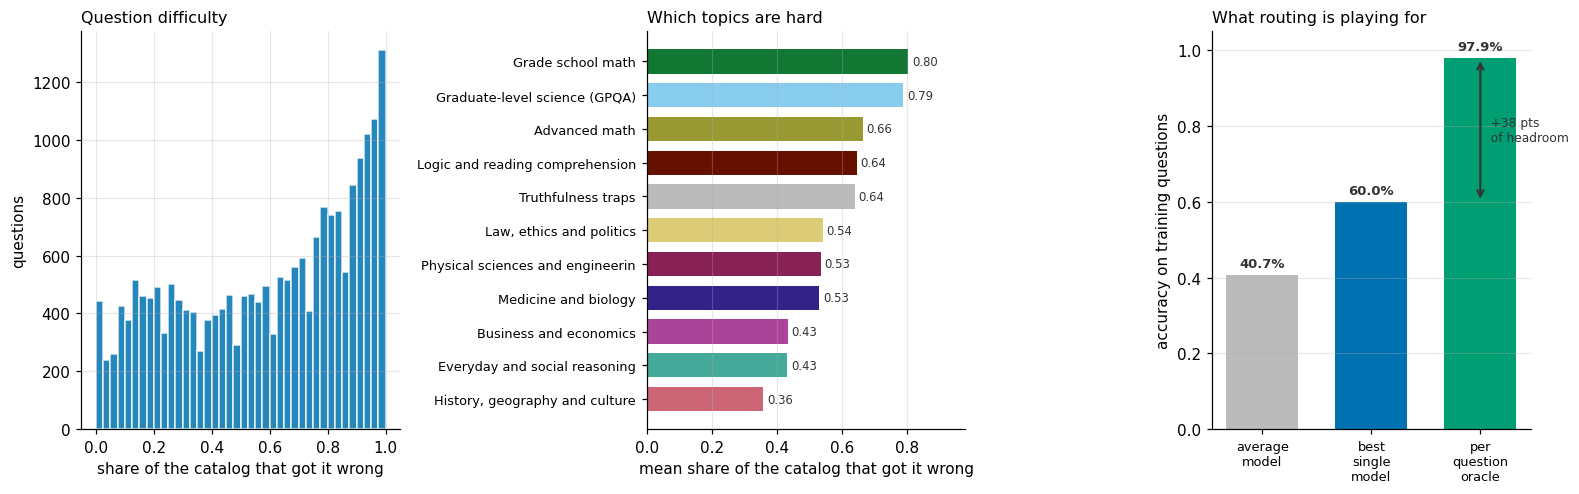

In [ ]:
#@title How hard is each question, and how much room is there to route? {display-mode: "form"}
_diff = np.mean(L[X_tr], axis=1)
_cats_tr = prompts.loc[X_tr, "category"].to_numpy()

fig, ax = plt.subplots(1, 3, figsize=(14.4, 4.6),
                       gridspec_kw=dict(width_ratios=[1, 1, 1]))

# --- the whole distribution ---------------------------------------------------------
ax[0].hist(_diff, bins=40, color=CB["blue"], alpha=.85, edgecolor="white", lw=.6)
ax[0].set_xlabel("share of the catalog that got it wrong")
ax[0].set_ylabel("questions")
ax[0].set_title("Question difficulty", fontsize=10.5, loc="left")
_easy = float((_diff < .1).mean()); _hard = float((_diff > .9).mean())

# --- difficulty by topic ------------------------------------------------------------
_order = sorted(TOPICS_ALL, key=lambda t: np.mean(_diff[_cats_tr == t]))
_mu = [float(np.mean(_diff[_cats_tr == t])) for t in _order]
ax[1].barh(range(len(_order)), _mu, color=[tcol(t) for t in _order], height=.72)
ax[1].set_yticks(range(len(_order)))
ax[1].set_yticklabels([t[:32] for t in _order], fontsize=8.4)
ax[1].set_xlabel("mean share of the catalog that got it wrong")
ax[1].set_xlim(0, min(1.0, max(_mu) * 1.22))
for i, v in enumerate(_mu):
    ax[1].text(v + .012, i, f"{v:.2f}", va="center", fontsize=7.6, color=CB["dark"])
ax[1].set_title("Which topics are hard", fontsize=10.5, loc="left")
ax[1].grid(axis="y", visible=False)

# --- the headroom a router is playing for -------------------------------------------
_acc_m   = 1 - np.mean(L[X_tr], axis=0)
_best    = float(_acc_m.max())
_mean    = float(_acc_m.mean())
_oracle  = float(1 - np.mean(np.min(L[X_tr], axis=1)))   # per question, the best model
_bars    = [("average model", _mean, CB["grey"]),
            ("best single model", _best, CB["blue"]),
            ("per question oracle", _oracle, CB["green"])]
ax[2].bar(range(3), [b[1] for b in _bars], color=[b[2] for b in _bars], width=.66)
ax[2].set_xticks(range(3))
ax[2].set_xticklabels([b[0].replace(" ", "\n") for b in _bars], fontsize=8.4)
ax[2].set_ylim(0, 1.05); ax[2].set_ylabel("accuracy on training questions")
for i, b in enumerate(_bars):
    ax[2].text(i, b[1] + .02, f"{b[1]:.1%}", ha="center", fontsize=8.6,
               fontweight="bold", color=CB["dark"])
ax[2].annotate("", xy=(2, _oracle), xytext=(2, _best),
               arrowprops=dict(arrowstyle="<->", color=CB["dark"], lw=1.4))
ax[2].text(2.02, (_best + _oracle) / 2, f"  +{100*(_oracle-_best):.0f} pts\n  of headroom",
           fontsize=8, color=CB["dark"], va="center")
ax[2].set_title("What routing is playing for", fontsize=10.5, loc="left")
ax[2].grid(axis="x", visible=False)

plt.tight_layout(); plt.show()

### 1.2: Meet the catalog: price against quality 🏷️

Now the `models` table. Cost against accuracy for all 112, with the models that arrive later drawn
as triangles, plus how big they are and who publishes them.

The line through the top left is the **frontier**: at each price, the best you can buy. Everything
below it is *dominated*, meaning some cheaper model is also more accurate, so a sane router should
never call it. Notice how few models are on that line, and notice that the frontier is a curve, not
a straight climb. Paying twice as much does not buy twice as much.

In [ ]:
#@title Price vs quality, and the Pareto frontier {display-mode: "form"}
_acc_m = 1 - np.mean(L[X_tr], axis=0)       # accuracy of every model
_is_tr = (models["pool"] == "train").to_numpy()

def pareto_front(c, a):
    """Indices of the models nobody beats on both axes: no cheaper model is also better."""
    o = np.argsort(c)
    keep, best = [], -np.inf
    for j in o:
        if a[j] > best:
            keep.append(int(j)); best = a[j]
    return np.array(keep)

def plot_catalog(view_option):
    # Determine visibility masks based on selection
    if view_option == "Both":
        mask = np.ones(len(models), dtype=bool)
    elif view_option == "train":
        mask = _is_tr
    elif view_option == "test":
        mask = ~_is_tr

    # Filter data for active models
    active_indices = np.where(mask)[0]
    sub_cost = cost[mask]
    sub_acc = _acc_m[mask]

    # Recalculate Pareto frontier for the filtered subset
    _front_sub = pareto_front(sub_cost, sub_acc)
    _front_idx = active_indices[_front_sub]  # Original array indices

    fig, ax = plt.subplots(figsize=(12, 6))

    # Plot Scatter Points based on visibility toggle
    if view_option in ["Both", "train"]:
        ax.scatter(cost[_is_tr], _acc_m[_is_tr], s=34, color=CB["blue"], alpha=.85,
                   lw=0, zorder=3, label=f"M_tr ({_is_tr.sum()} models, available today)")

    if view_option in ["Both", "test"]:
        ax.scatter(cost[~_is_tr], _acc_m[~_is_tr], s=34, marker="^", color=CB["orange"],
                   alpha=.9, lw=0, zorder=3, label=f"M_te ({(~_is_tr).sum()} models, not available yet)")

    # Plot updated Pareto Frontier for active selection
    ax.plot(cost[_front_idx], _acc_m[_front_idx], "-", lw=1.6, color=CB["dark"], alpha=.65,
            zorder=2, label=f"Pareto front ({view_option.lower()})")

    ax.scatter(cost[_front_idx], _acc_m[_front_idx], s=90, facecolor="none",
               edgecolor=CB["dark"], lw=1.3, zorder=4)

    # Annotate most accurate model in the selected view
    _star = active_indices[np.argmax(sub_acc)]
    model_label = str(models.loc[_star, 'model_name']).split('__', 1)[-1][:22]
    ax.annotate(f"most accurate\n{model_label}",
                (cost[_star], _acc_m[_star]), xytext=(-16, 16),
                textcoords="offset points", fontsize=7.8, color=CB["dark"], ha="right",
                arrowprops=dict(arrowstyle="->", color=CB["dark"], lw=.9))

    ax.set_xlabel("model cost")
    ax.set_ylabel("accuracy on training questions")
    ax.set_title(f"Price against quality ({view_option.lower()})", fontsize=16, loc="center")
    ax.legend(fontsize=10, loc="upper left")

    plt.tight_layout()
    plt.show()

    # Dynamic summary prints
    print(f"{len(sub_cost)} visible models | "
          f"{len(_front_idx)} on the frontier | "
          f"{len(sub_cost) - len(_front_idx)} dominated")

# --- Toggle Widget (3 distinct, non-both-off options) ---
toggle = widgets.RadioButtons(
    options=["Both", "train", "test"],
    value="Both",
    description="Show Models:",
    disabled=False
)

widgets.interactive(plot_catalog, view_option=toggle)

interactive(children=(RadioButtons(description='Show Models:', options=('Both', 'train', 'test'), value='Both'…

### 1.3: Who is best at what? 🏆

For each of the 11 topics we take the **most accurate models on that topic** and put those models in one grid. Each square is one model's accuracy on one topic; the **circled** square in every column is that topic's winner.

Notice that no single row is circled across all columns, which is the entire reason a router can beat any single model!

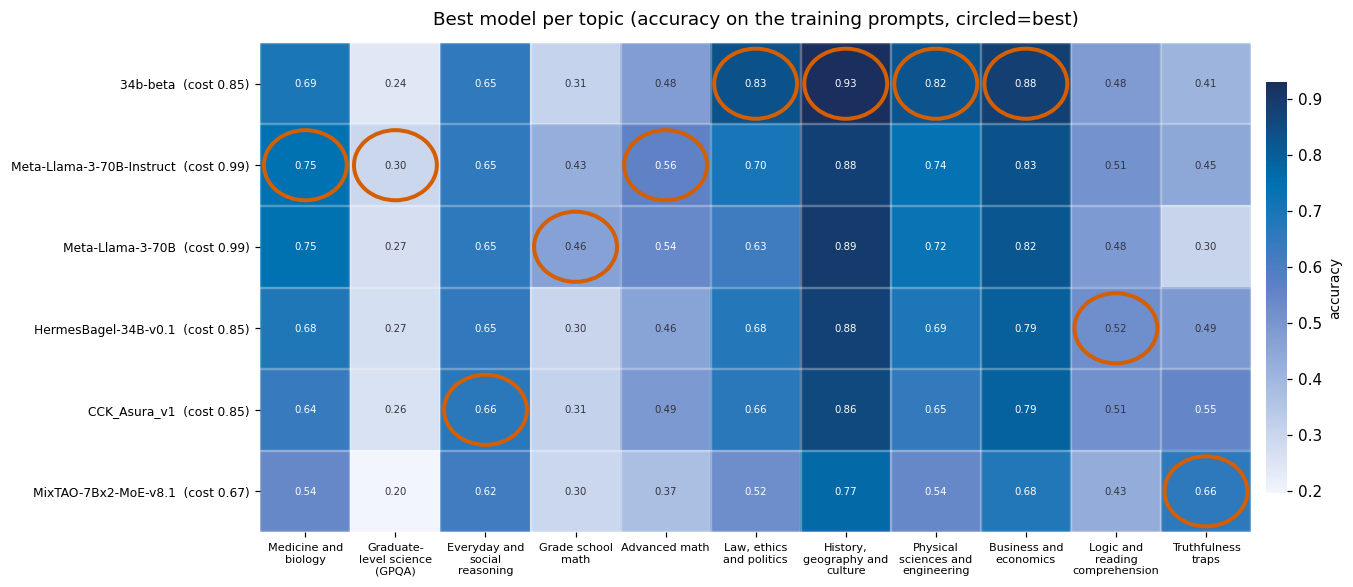

In [ ]:
#@title Best model per topic, as a heatmap {display-mode: "form"}
TOP_N = 1          # how many models per topic enter the grid
_short = lambda s: str(s).split("__", 1)[-1]

_cats_tr = prompts.loc[X_tr, "category"].to_numpy()
topics   = list(pd.Series(_cats_tr).value_counts().index)     # biggest topic first

# accuracy of every model on every topic, measured on the training prompts
acc_topic = np.full((len(models), len(topics)), np.nan, np.float32)
for t, tp in enumerate(topics):
    acc_topic[:, t] = 1 - np.nanmean(L[X_tr[_cats_tr == tp]], axis=0)

# the union of the top TOP_N models per topic, ordered by topics won, then by mean accuracy
keep = []
for t in range(len(topics)):
    for m in np.argsort(-acc_topic[:, t])[:TOP_N]:
        if m not in keep:
            keep.append(int(m))
_wins = np.array([(np.argmax(acc_topic, axis=0) == m).sum() for m in keep])
keep  = [keep[i] for i in np.lexsort((-np.nanmean(acc_topic[keep], axis=1), -_wins))]
H = acc_topic[keep]

_cmap = LinearSegmentedColormap.from_list("relay_blue",
        ["#f2f5fb", "#a8bde2", "#5f81c6", "#0072B2", "#1b2f5e"])
fig, ax = plt.subplots(figsize=(12.4, 0.44 * len(keep) + 2.8))
im = ax.imshow(H, cmap=_cmap, aspect="auto", vmin=np.nanmin(H), vmax=np.nanmax(H))

ax.set_xticks(range(len(topics)))
ax.set_xticklabels(["\n".join(textwrap.wrap(t, 13)) for t in topics], fontsize=7.4)
ax.set_yticks(range(len(keep)))
ax.set_yticklabels([f"{_short(models.loc[m, 'model_name'])[:30]}  (cost {cost[m]:.2f})"
                    for m in keep], fontsize=8)
ax.set_xticks(np.arange(-.5, len(topics), 1), minor=True)
ax.set_yticks(np.arange(-.5, len(keep), 1), minor=True)
ax.grid(which="minor", color="white", lw=1.6); ax.tick_params(which="minor", length=0)

def _ink(v):
    """White or dark ink, picked from the cell's own luminance rather than a guessed cut."""
    r, g, b, _ = _cmap(im.norm(v))
    return "white" if (0.2126 * r + 0.7152 * g + 0.0722 * b) < 0.55 else "#33333d"

for t in range(len(topics)):
    for r in range(len(keep)):
        ax.text(t, r, f"{H[r, t]:.2f}", ha="center", va="center",
                fontsize=6.6, color=_ink(H[r, t]), zorder=4)
for t in range(len(topics)):                                   # circle the winner of each column
    w = int(np.argmax(H[:, t]))
    ax.add_patch(Ellipse((t, w), 0.92, 0.86, fill=False, ec="#D55E00", lw=2.6, zorder=5))
ax.grid(axis="x", visible=False), ax.grid(axis="y", visible=False)
ax.set_title(f"Best model per topic (accuracy on the training prompts, circled=best)", fontsize=12, pad=12, loc="center")
cb = fig.colorbar(im, ax=ax, pad=.015, fraction=.02)
cb.set_label("accuracy", fontsize=9); cb.outline.set_visible(False)
for s in ax.spines.values(): s.set_visible(False)
plt.tight_layout(); plt.show()


### 1.4: Do the topics sit apart? 🗺️

We inspect visually how $\phi(x)$, the 384 numbers, represent the semantics of each question by checking if those in the same topics are clustered. Below is a PCA of the embeddings down to two dimensions, drawn once per topic: the topic in blue against every other training prompt in grey.

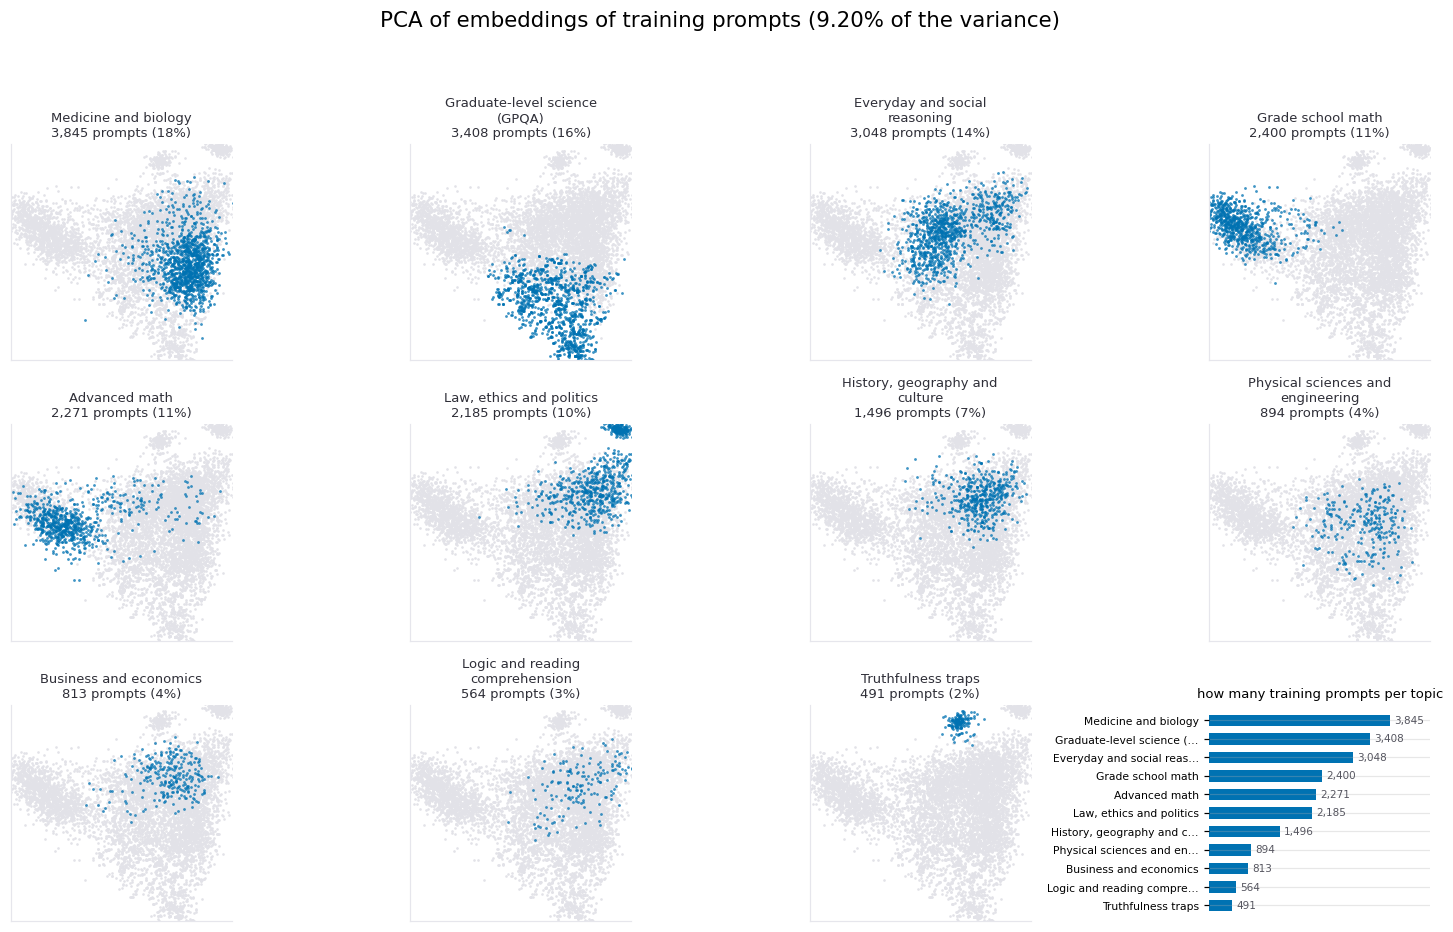

the 2 components drawn here hold 9.2% of the variance in phi(x); the other 382 directions are what the network actually gets to use


In [ ]:
#@title Topics in embedding space (PCA) {display-mode: "form"}

Z_tr, Z_val, Z_te = Z[X_tr], Z[X_val], Z[X_te]
_pca = PCA(n_components=2, random_state=SEED).fit(Z_tr)
_XY  = _pca.transform(Z_tr)
_ev  = _pca.explained_variance_ratio_
_cats_tr = prompts.loc[X_tr, "category"].to_numpy()
topics = list(pd.Series(_cats_tr).value_counts().index)

_sub = RNG.choice(len(_XY), size=min(7000, len(_XY)), replace=False)   # a readable backdrop
_XYs, _cs = _XY[_sub], _cats_tr[_sub]
ACCENT = "#0072B2"

fig, axes = plt.subplots(3, 4, figsize=(13.2, 8.6))
# one common frame for the 11 scatter panels (the 12th is a bar chart, so no shared axes)
_xl = (np.percentile(_XY[:, 0], .2), np.percentile(_XY[:, 0], 99.8))
_yl = (np.percentile(_XY[:, 1], .2), np.percentile(_XY[:, 1], 99.8))
for i, tp in enumerate(topics):
    ax = axes.flat[i]; sel = _cs == tp
    ax.scatter(_XYs[~sel, 0], _XYs[~sel, 1], s=3, c="#e2e2e8", lw=0, rasterized=True)
    ax.scatter(_XYs[sel, 0],  _XYs[sel, 1],  s=3.4, c=ACCENT, lw=0, alpha=.75, rasterized=True)
    n = int((_cats_tr == tp).sum())
    ax.set_title("\n".join(textwrap.wrap(tp, 24)) + f"\n{n:,} prompts ({n / len(_cats_tr):.0%})",
                 fontsize=8.6, color="#2f2f38", pad=5)
    ax.set_xlim(*_xl); ax.set_ylim(*_yl); ax.set_xticks([]); ax.set_yticks([])
    for s in ax.spines.values(): s.set_color("#e6e6ec")

axL = axes.flat[11]                                        # the spare panel: how big each topic is
_order = topics[::-1]; _vals = [int((_cats_tr == t).sum()) for t in _order]
axL.barh(range(len(_order)), _vals, color=ACCENT, height=.62)
axL.set_yticks(range(len(_order)))
axL.set_yticklabels([t if len(t) <= 26 else t[:24] + "…" for t in _order], fontsize=7)
axL.set_xticks([]); axL.set_title("how many training prompts per topic", fontsize=8.6, pad=5)
for i, v in enumerate(_vals):
    axL.text(v + 90, i, f"{v:,}", va="center", fontsize=6.8, color="#55555f")
axL.set_xlim(0, max(_vals) * 1.22)
for s in axL.spines.values(): s.set_visible(False)

fig.suptitle(f"PCA of embeddings of training prompts ({_ev[0]+_ev[1]:.2%} of the variance)",
             fontsize=14,  ha="center")
fig.tight_layout(rect=[0, 0, 1, .945]); plt.show()
print(f"the 2 components drawn here hold {_ev[:2].sum():.1%} of the variance in phi(x); "
      f"the other {D - 2} directions are what the network actually gets to use")


### 1.5: How good are the models, and do the splits agree? 📊

For each model, its accuracy ($1$ minus its mean loss over a set of prompts) is computed twice, once over the 21,415 training prompts and once over the 3,567 validation prompts. The two accuracies are compared as histograms (left panel) and scatter plots (right pannel). Visualizations show they are very highly correlated.

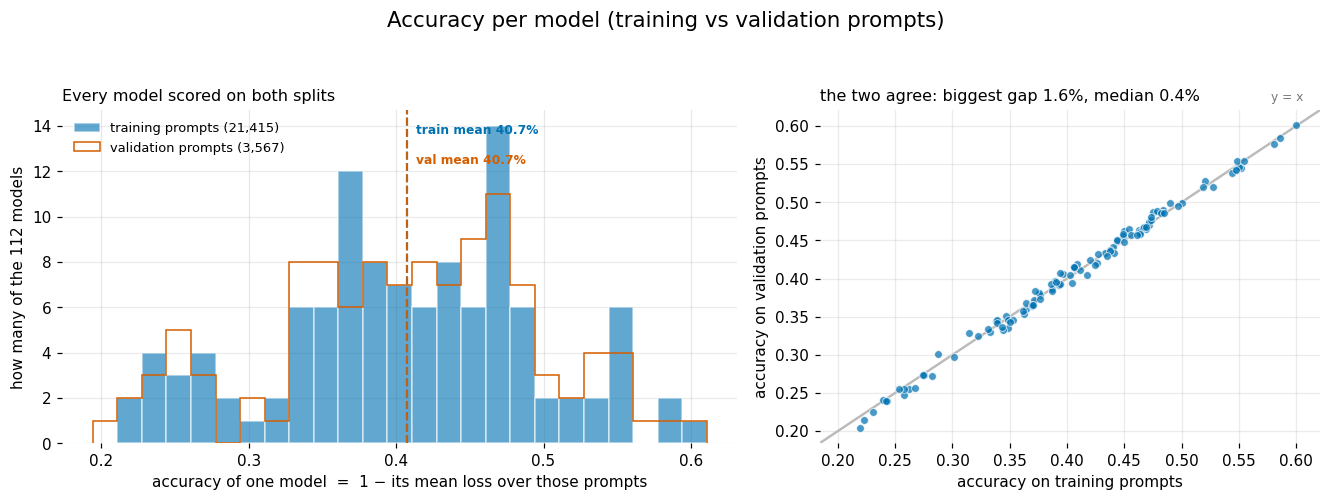

In [ ]:
#@title Accuracy per model, training vs validation {display-mode: "form"}
TRAIN_C, VAL_C = "#0072B2", "#D55E00"

acc_tr_m  = 1 - np.nanmean(L[X_tr],  axis=0)      # one number per model, straight out of L
acc_val_m = 1 - np.nanmean(L[X_val], axis=0)
_bins = np.linspace(min(acc_tr_m.min(), acc_val_m.min()) - .01,
                    max(acc_tr_m.max(), acc_val_m.max()) + .01, 26)

fig, (ax, ax2) = plt.subplots(1, 2, figsize=(12.2, 4.6), gridspec_kw=dict(width_ratios=[1.35, 1]))
ax.hist(acc_tr_m, bins=_bins, color=TRAIN_C, alpha=.62, edgecolor="white", lw=.8,
        label=f"training prompts ({len(X_tr):,})")
ax.hist(acc_val_m, bins=_bins, histtype="step", color=VAL_C, lw=2.2,
        label=f"validation prompts ({len(X_val):,})")
for v, c, lab, dy in [(acc_tr_m.mean(), TRAIN_C, "train mean", 0),
                      (acc_val_m.mean(), VAL_C, "val mean", 1)]:
    ax.axvline(v, color=c, ls="--", lw=1.4, alpha=.9)
    ax.annotate(f"{lab} {v:.1%}", (v, ax.get_ylim()[1] * (.93 - .09 * dy)), xytext=(6, 0),
                textcoords="offset points", fontsize=8, color=c, fontweight="bold")
ax.set_xlabel("accuracy of one model  =  1 − its mean loss over those prompts")
ax.set_ylabel(f"how many of the {len(models)} models")
ax.set_title("Every model scored on both splits", fontsize=10.5, loc="left")
ax.legend(fontsize=8.5, frameon=False); ax.grid(alpha=.25, axis="y"); ax.set_axisbelow(True)

_lo = min(acc_tr_m.min(), acc_val_m.min()) - .02
_hi = max(acc_tr_m.max(), acc_val_m.max()) + .02
ax2.plot([_lo, _hi], [_lo, _hi], color="#BBBBBB", lw=1.6, zorder=1)
ax2.scatter(acc_tr_m, acc_val_m, s=26, c=TRAIN_C, alpha=.72, lw=.6, edgecolor="white", zorder=3)
ax2.annotate("y = x", (_hi, _hi), xytext=(-32, 6), textcoords="offset points",
             fontsize=8, color="#77777f")
_gap = np.abs(acc_tr_m - acc_val_m)
ax2.set_xlabel("accuracy on training prompts"); ax2.set_ylabel("accuracy on validation prompts")
ax2.set_title(f"the two agree: biggest gap {_gap.max():.1%}, median {np.median(_gap):.1%}",
              fontsize=10.5, loc="left")
ax2.grid(alpha=.25); ax2.set_axisbelow(True); ax2.set_xlim(_lo, _hi); ax2.set_ylim(_lo, _hi)
for a in (ax, ax2):
    for s in a.spines.values(): s.set_visible(False)
fig.suptitle("Accuracy per model (training vs validation prompts)",
             fontsize=14, ha="center")
fig.tight_layout(rect=[0, 0, 1, .93]); plt.show()

### 8. Turning the dial, before there is a router 🎛️

The routing rule is $\arg\min_m \big[\gamma^{(m)}(x) + \lambda\, c^{(m)}\big]$. The whole notebook is
about computing $\gamma$ well, and we have not built anything that can do that yet. But we can still
watch the rule work, by putting the crudest possible $\gamma$ in its place: each model's **measured**
error over the training prompts, one number per model, the same for every question.

That is a router with no idea what the question is. It picks one model and calls it for everything.
Drag $\lambda$ and watch which one:

- $\lambda = 0$: no cost concern, so the pick is simply the most accurate model in the catalog.
- $\lambda$ large: cost is of great concern, so the pick the cheapest model.
- in between: the winner walks down the price list, one model at a time.

The left panel makes the argmin geometric. Every model is a dot in (cost, error), and the dashed
line is the set of points scoring exactly what the winner scores, with slope $-\lambda$ Sweeping that line up from below, the winner is the first dot it touches. The right panel is the same choice as arithmetic: each bar is one model's error with $\lambda \cdot \text{cost}$ stacked on top.

**What is still missing is the whole point.** This picks one model for *every* question. Part 2 makes
$\gamma$ depend on $x$, and that single change is what turns a fixed choice into routing.


In [ ]:
#@title The routing rule with measured error, lambda on a slider {display-mode: "form"}

ERR_C, COST_C, MUTED, WIN_C = "#0072B2", "#D55E00", "#BBBBBB", "#332288"
_short = lambda s: str(s).split("__", 1)[-1]
TOP_BARS = 8

_acc_m = 1 - np.mean(L[X_tr], axis=0)       # Accuracy of every model
err_measured = 1 - _acc_m                   # Measured error
_is_tr = (models["pool"] == "train").to_numpy()

# --- Interactive Show Tradeoff ---
def show_tradeoff(lam, view_option):
    # Filter active models based on visibility selection
    if view_option == "Both":
        mask = np.ones(len(models), dtype=bool)
    elif view_option == "Train":
        mask = _is_tr
    elif view_option == "Test":
        mask = ~_is_tr

    active_indices = np.where(mask)[0]
    sub_cost = cost[mask]
    sub_acc = _acc_m[mask]
    sub_err = err_measured[mask]

    # Compute router score: minimize (err + lam * cost) over active models
    sub_score = sub_err + lam * sub_cost
    win_sub = int(np.argmin(sub_score))
    win = active_indices[win_sub]

    # Recalculate Pareto frontier for accuracy vs cost among active models
    _front_sub = pareto_front(sub_cost, sub_acc)
    _front_idx = active_indices[_front_sub]

    fig, (a1, a2) = plt.subplots(1, 2, figsize=(12.6, 4.9),
                                 gridspec_kw=dict(width_ratios=[1, 1.15]))

    # --- LEFT PANEL: Cost vs Accuracy & Pareto Frontier ---
    _other = np.setdiff1d(active_indices, [win])
    a1.scatter(cost[_other], _acc_m[_other], s=26, c=MUTED, lw=0, zorder=2)

    # Pareto frontier line in accuracy space
    a1.plot(cost[_front_idx], _acc_m[_front_idx], "-", lw=1.4, color=CB["dark"],
            alpha=.55, zorder=2, label="Pareto front")

    # Indifference line in accuracy space: acc - lam * cost = const
    _xs = np.array([-0.02, 1.06])
    a1.plot(_xs, _acc_m[win] - lam * (_xs - cost[win]), color=WIN_C, lw=1.6,
            ls="--", alpha=.85, zorder=3, label=f"Same objective score under this λ")

    # Highlight winning model
    a1.scatter([cost[win]], [_acc_m[win]], s=170, c=WIN_C, zorder=5, edgecolor="white", lw=1.6)

    _left = cost[win] < 0.5
    a1.annotate(f"{_short(models.loc[win, 'model_name'])[:26]}\n"
                f"acc {_acc_m[win]:.2f} - {lam:.3g}x{cost[win]:.2f} = {_acc_m[win] - lam*cost[win]:.3f}",
                (cost[win], _acc_m[win]), xytext=(11 if _left else -9, -30),
                textcoords="offset points", fontsize=8, ha="left" if _left else "right",
                color=WIN_C, fontweight="bold")

    a1.set_xlim(-0.02, 1.06)
    a1.set_ylim(_acc_m.min() - .04, _acc_m.max() + .06)
    a1.set_xlabel("cost")
    a1.set_ylabel("measured accuracy on the training prompts")
    a1.set_title(f"accuracy vs cost ({view_option.lower()})", fontsize=10.5, loc="left")
    a1.grid(alpha=.25); a1.set_axisbelow(True)
    a1.legend(fontsize=8.5, frameon=False, loc="lower right", bbox_to_anchor=(1, 1.0))
    # --- RIGHT PANEL: Top Bounded Scores (Error + Lambda * Cost) ---
    k = min(TOP_BARS, len(active_indices))
    sub_ordr = np.argsort(sub_score)[:k][::-1]
    ordr = active_indices[sub_ordr]
    scores_ordr = sub_score[sub_ordr]

    y = np.arange(len(ordr))
    a2.barh(y, err_measured[ordr], color=ERR_C, height=.62, label="error")
    a2.barh(y, lam * cost[ordr], left=err_measured[ordr] + 0.004, color=COST_C, height=.62,
            label="lambda x cost")
    a2.set_yticks(y)
    a2.set_yticklabels([("◀ " if m == win else "") + _short(models.loc[m, "model_name"])[:26]
                        for m in ordr], fontsize=8.4)

    for t, m in zip(a2.get_yticklabels(), ordr):
        if m == win: t.set_color(WIN_C); t.set_fontweight("bold")
    for i, (m, sc) in enumerate(zip(ordr, scores_ordr)):
        a2.text(sc + .012, i, f"{sc:.3f}", va="center", fontsize=8,
                color=WIN_C if m == win else "#55555f",
                fontweight="bold" if m == win else "normal")

    a2.set_xlim(0, max(scores_ordr) * 1.2)
    a2.set_xlabel("error + lambda*cost (smaller is better)")
    a2.set_title(f"the {k} best scores at this lambda", fontsize=10.5, loc="left")
    a2.legend(fontsize=8.5, frameon=False, ncol=2, loc="lower right", bbox_to_anchor=(1, 1.0))
    a2.grid(alpha=.25, axis="x"); a2.set_axisbelow(True); a2.tick_params(left=False)

    for ax in (a1, a2):
        for s in ax.spines.values(): s.set_visible(False)

    fig.suptitle(f"lambda = {lam:.3g} → this router would always call "
                 f"{_short(models.loc[win, 'model_name'])[:34]}"
                 f"  (acc {_acc_m[win]:.1%}, error {err_measured[win]:.1%}, cost {cost[win]:.2f})",
                 fontsize=11.5, x=.008, ha="left", y=1.0)
    fig.tight_layout(rect=[0, 0, 1, .94]); plt.show()

# --- Controls ---
toggle = widgets.RadioButtons(
    options=["Both", "Train", "Test"],
    value="Both",
    description="Show Models:",
    disabled=False
)

lam_slider = widgets.FloatSlider(value=0.1, min=0, max=1, step=0.01,
    description="lambda", layout=widgets.Layout(width='500px')
)

widgets.interactive(show_tradeoff, lam=lam_slider, view_option=toggle)

interactive(children=(FloatSlider(value=0.1, description='lambda', layout=Layout(width='500px'), max=1.0, step…

# Part 2. The Neural Network Router

With the data and knowledge necessary, we can start build the router which RelayAI will deploy next.
 It will be trained on the training questions `X_tr` for the currently available models `M_tr`.

Remember the goal: for each incoming prompt, find the model with the smallest sum of predicted
error and cost. So we need a $\gamma$ that turns one question into one predicted error per model.
We use a small **two layer neural network**:

$$ \gamma_{\text{mlp}}(x) \;=\; \sigma\Big(\, W_2\,\operatorname{ReLU}\big(W_1 \phi(x) + b_1\big) + b_2 \,\Big) $$

Two layers means two `nn.Linear` blocks, a hidden one and an output one, with a ReLU between them
and a sigmoid at the end. Read left to right, the way the numbers actually flow:

<center>

| piece | shape | what it does |
|---|---|---|
| $\phi(x)$ | $384$ | the embedding of the question (precomputed)|
| $W_1, b_1$ | $128 \times 384$, $128$ | **hidden layer**: maps the embedding into 128 features |
| $\operatorname{ReLU}$ | N/A | **Activation function**: nonlinearity which achieves universal approximation |
| $W_2, b_2$ | $M \times 128$, $M$ | **output layer**: one row per model in the pool |
| $\sigma$ | N/A | the sigmoid, which squeezes every output in $[0, 1]$ |
</center>

The output is a vector of $M$ numbers, one predicted error per model, each between 0 and 1.

**Note how the two layers divide the work**, because Part 3 turns on exactly this. The hidden layer
is **shared**: every model in the pool reads the same 128 features, and its size does not depend on
how many models there are. The output layer gives **one prediction per model**: model $m$ owns row $m$ of $W_2$ plus
one bias, which is $128 + 1 = 129$ numbers that describe that model and nothing else. Adding a model
to the catalog means growing $W_2$ by a row and fitting those 129 numbers from scratch.


**What is the loss function?**

Our target is simple: for each prompt and model, predict whether the answer is right or wrong. That result is
already recorded in `errors.npy` as $L$ (1 for wrong, 0 for right) as training data, and the router learns to
predict it. Written out per pair, $\ell^{(m)}(x)=L[x][m]$ is the label for model $m$ on prompt $x$.

The router only has to make its prediction $\gamma^{(m)}(x)$ agree with $\ell^{(m)}(x)$. The simplest
way to say "agree" is to make the gap between the two small, and to square that gap so that
overshooting and undershooting both count. That is the **mean squared error**.

**The loss, in math.**
$$ \text{MSE Loss} \;=\; \frac{1}{N}\sum_{x,\,m}\Big(\gamma^{(m)}(x) \;-\; \ell^{(m)}(x)\Big)^2 $$

Plainly, the squared gap $\big(\gamma^{(m)}(x) - \ell^{(m)}(x)\big)^2$ is the term being minimized.
When the model was wrong ($\ell = 1$) that term shrinks by pushing $\gamma$ up toward 1, and when the
model was right ($\ell = 0$) it shrinks by pushing $\gamma$ down toward 0. Again, the label $\ell$
comes straight from `errors.npy`, only $\gamma$ is learned.

Note where the range comes from. The labels $\ell$ are 0 or 1, and the network's final **sigmoid**
puts $\gamma$ in $[0, 1]$ too, so prediction and target live on the same scale and each squared gap
is at most 1. Strictly speaking, the routing rule would survive without the sigmoid (since it does not change the argmin). However, matching the label range keeps the squared error well behaved and lets you read $\gamma$ as *how likely is this model to get this one wrong*.

Below, you will implement the main routing logic

$$ r(x) \;=\; \arg\min_{m \in [M]} \Big[\, \gamma^{(m)}(x) \;+\; \lambda \cdot c^{(m)} \,\Big] $$

inside the function `route_argmin`.


In [ ]:
def route_argmin(gamma, costs, lam):
    # 🎯 TODO: compute the argmin over models of gamma + lambda * cost. One pick per prompt.
    # Hint 1: use np.argmin(..., axis=1) to pick the best model for each prompt.
    # Hint 2: use costs[None, :] to make costs the right shape for broadcasting with gamma.
    return ...

In [ ]:
# @title Other helper functions for routing and evaluation {display-mode: "form"}
def evaluate(gamma, pool, idx, lam):
    """Route these prompts over this pool at this lambda. Returns (accuracy, mean cost, picks)."""
    picks = pool[route_argmin(gamma, cost[pool], lam)]
    return float(1 - np.nanmean(L[idx, picks])), float(cost[picks].mean()), picks

def sweep(gamma, pool, idx, lambdas):
    """Trace the whole accuracy against cost curve by turning the dial."""
    out = [evaluate(gamma, pool, idx, l)[:2] for l in lambdas]
    return np.array([a for a, _ in out]), np.array([c for _, c in out])

def frontier(acc_c, cost_c):
    """Sort a swept curve by cost and take the running best accuracy, so it is monotone."""
    o = np.argsort(cost_c)
    return cost_c[o], np.maximum.accumulate(acc_c[o])

LAMBDAS = np.linspace(0.0, 10.0, 1000) #np.concatenate([[0.0], np.logspace(-2.5, 0.7, 22)])
print(f"lambda grid: {len(LAMBDAS)} values from {LAMBDAS.min():.3g} to {LAMBDAS.max():.3g}")


### The data loader
Your team implement NNs in PyTorch. This means you need to implement two things for handling data: a `Dataset` class storing all information, and a `DataLoader` that turns that into shuffled batches. Each of our data points is a pair: the feature is the embedding $\phi(x)$, and the target is the vector of error labels for the 70 models available today.

We keep track of **two** dataloader objects, one for training and one for evaluation. The training one is shuffled and drives the weight updates. The validation one is not shuffled and never touches a gradient; it exists purely to be scored.

In [ ]:
class RelayDataset(Dataset):
    """Serves one training example at a time: a prompt embedding and its error labels.

    X : (n_prompts, 384) feature vectors (prompt embeddings)
    Y : (n_prompts, n_models) error labels (1 = wrong, 0 = right)
    """
    def __init__(self, X, Y):
        self.X = torch.as_tensor(np.asarray(X), dtype=torch.float32)
        self.Y = torch.as_tensor(np.asarray(Y), dtype=torch.float32)
    def __len__(self):
        # 🎯 TODO: return the number of data points in this dataset
        return ???

    def __getitem__(self, i):
        # 🎯 TODO: return the i-th data point as a tuple in this dataset
        return ???, ???

# The two sets the router is fitted against: the training questions it learns from, and the
# validation questions it is only ever *scored* on. Both are restricted to M_tr, today's fleet.
train_ds = RelayDataset(Z_tr,  L[np.ix_(X_tr,  M_tr)])
val_ds   = RelayDataset(Z_val, L[np.ix_(X_val, M_tr)])

BATCH_MLP = 512
train_loader = DataLoader(train_ds, batch_size=BATCH_MLP, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_MLP, shuffle=False)   # no shuffle, we only score

# Peek at one batch to see what the data looks like
_xb, _yb = next(iter(train_loader))
print(f"training questions   : {len(train_ds):,}  ->  {len(train_loader)} batches of {BATCH_MLP} samples")
print(f"validation questions : {len(val_ds):,}  ->  {len(val_loader)} batches")
print(f"one batch            : embeddings {tuple(_xb.shape)}, labels {tuple(_yb.shape)}")

### The network

The architecture of the formula above, in PyTorch. Some components you need:

<center>

| In PyTorch | What it is |
| ---        | ---        |
|  `nn.Linear(dim_in, dim_out)` | A linear layer (with bias) from dimension `dim_in` to `dim_out` |
| `nn.ReLU()` | The ReLU activation function |
| `nn.Dropout(p)` | Dropout regularization between two layers: During training, randomly zeroes some of the elements of the input tensor with probability `p`.|
| `torch.sigmoid` | The sigmoid function |
</center>

In [ ]:
class MLPRouter(nn.Module):
    """gamma_mlp(x) = sigmoid(W2 ReLU(W1 phi(x) + b1) + b2)."""
    def __init__(self, d_in, n_models, hidden=128, p_drop=0.0):
        super().__init__()

        # 🎯 TODO: Initialize the layers of the MLP
        self.fc1  = ...         # fully connected, dim 384 -> dim 128
        self.relu = ...         # relu activation
        self.drop = ...         # dropout between fc1 and fc2, with probability p_drop
        self.fc2  = ...         # fully connected, one output row per model, 128 -> M

    def forward(self, z):

        # 🎯 TODO: Compute the forward pass for this MLP
        # Hint: Use the layers defined in `__init__` to transform the input `z` step by step as in the formula.
        return ...

def mse(pred, tgt):
    """The mean squared error loss between two tensors `pred` and `tgt`."""

    # 🎯 TODO: Implement the mean squared error function
    return ...

In [ ]:
# A small test to see that the network is wired up correctly
_probe = MLPRouter(D, len(M_tr))
print(_probe)
print(f"\none batch of 4 questions in, {tuple(_probe(torch.zeros(4, D)).shape)} out: "
      f"a predicted error for each of the {len(M_tr)} models")
print(f"{sum(p.numel() for p in _probe.parameters()):,} numbers to fit: "
      f"a shared {D} x 128 trunk, then one row of 129 for each of those models")

### The training loop, the validation loop, and one honest question about regularisation 🔁

Two functions, deliberately kept apart because they do genuinely different things:
<center>

| | `train_one_epoch` | `validate` |
|---|---|---|
| mode | `net.train()`, dropout **on** | `net.eval()`, dropout **off** |
| gradients | computed, weights updated | `torch.no_grad()`, nothing moves |
| data | the training questions | the validation questions |
| what it is for | fitting | finding out whether the fitting generalised |
</center>

**Does this network need regularising?** It is worth asking rather than assuming. The router has
about 58,000 parameters and roughly 21,000 training questions, so parameters and examples are the
same order of magnitude, which is the regime where a network starts memorising. On the other hand
each question carries 70 labels, not one, so the *supervision* is far denser than the question count
suggests. The two arguments point in opposite directions, so we settle it by measurement: train the
same network twice, once plain and once with **dropout 0.2** between the layers and **weight decay
1e-4** on the optimiser, and read the validation curves.

Both runs also use **early stopping**, in the mild form: we always run the full 30 epochs, but keep
the checkpoint from the epoch with the lowest validation loss rather than whatever the last epoch
happened to leave behind. It costs nothing and it is the single most reliable guard against
overfitting there is.

In [ ]:
def train_one_epoch(net, loader, opt):
    """One pass over the training questions, updating the weights. Returns the mean loss."""
    net.train()   # set to training mode; dropout ON
    total_loss, n = 0.0, 0
    # 🎯 TODO: complete the logic to train an NN `net` for one epoch
    for xb, yb in loader: # loop over batches of questions
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        opt.??? # reset gradients before the next step
        loss = ??? # compute the loss for this batch
        loss.???   # perform backpropagation to compute gradients
        opt.??? # update the model parameters based on the gradients
        total_loss += loss.item() * len(xb)
        n += len(xb)

    return total_loss / n


@torch.no_grad()
def validate(net, loader):
    """One pass over the validation questions, scoring only. No gradients, no updates."""
    net.eval()          # dropout OFF, this is the deployed behaviour
    tot, n = 0.0, 0
    for xb, yb in loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        tot += mse(net(xb), yb).item() * len(xb); n += len(xb)
    return tot / n


def train_mlp(train_loader, val_loader, n_models, epochs=30, lr=3e-3, hidden=128,
              p_drop=0.0, weight_decay=0.0, verbose=True, tag=""):
    """Fit an MLPRouter, tracking train and validation loss every epoch.

    Returns (best_net, history). `best_net` is restored to the epoch with the lowest
    validation loss, which is early stopping without stopping early: we always run the
    full budget, but we keep the checkpoint that generalised best rather than the last one.
    """
    torch.manual_seed(SEED)
    net = MLPRouter(D, n_models, hidden, p_drop).to(DEVICE)
    opt = torch.optim.Adam(net.parameters(), lr=lr, weight_decay=weight_decay)

    hist = {"train": [], "val": []}
    best_val, best_state, best_ep = float("inf"), None, -1
    for ep in range(epochs):
        tr = train_one_epoch(net, train_loader, opt)
        va = validate(net, val_loader)
        hist["train"].append(tr); hist["val"].append(va)
        if va < best_val:
            best_val, best_ep = va, ep
            best_state = {k: v.detach().clone() for k, v in net.state_dict().items()}
        if verbose and (ep % 5 == 0 or ep == epochs - 1):
            print(f"  epoch {ep:2d}   train {tr:.4f}   val {va:.4f}")

    net.load_state_dict(best_state)
    net.eval()
    hist["best_epoch"], hist["best_val"], hist["tag"] = best_ep, best_val, tag
    if verbose:
        print(f"  kept epoch {best_ep} (val {best_val:.4f})")
    return net, hist


EPOCHS_MLP = 30
t0 = time.time()

print("A. no regularisation")
net_plain, hist_plain = train_mlp(train_loader, val_loader, len(M_tr),
                                  epochs=EPOCHS_MLP, p_drop=0.0, weight_decay=0.0,
                                  tag="no regularisation")
print("\nB. dropout 0.2 + weight decay 1e-4")
net_reg, hist_reg = train_mlp(train_loader, val_loader, len(M_tr),
                              epochs=EPOCHS_MLP, p_drop=0.2, weight_decay=1e-4,
                              tag="dropout 0.2 + weight decay 1e-4")

print(f"\nboth trained in {time.time() - t0:.1f}s on {DEVICE}")

Now read the curves. The signature of overfitting is the two lines **separating**: training loss
keeps falling because the network is memorising, while validation loss flattens and then turns back
up because none of that memorising transfers. The right panel plots the distance between them
directly.

Whichever setting validated better is the one that gets deployed as `mlp_router`, decided by the
number rather than by preference.

In [ ]:
#@title Loss per epoch, and does regularization earn its keep? {display-mode: "form"}
fig, ax = plt.subplots(1, 2, figsize=(13.0, 4.6),
                       gridspec_kw=dict(width_ratios=[1.25, 1]))

_eps = np.arange(1, EPOCHS_MLP + 1)
for h, c in [(hist_plain, CB["blue"]), (hist_reg, CB["vermillion"])]:
    ax[0].plot(_eps, h["train"], "-",  lw=1.9, color=c, label=f"{h['tag']}, train")
    ax[0].plot(_eps, h["val"],   "--", lw=1.9, color=c, alpha=.85, label=f"{h['tag']}, val")
    ax[0].scatter([h["best_epoch"] + 1], [h["best_val"]], s=90, color=c,
                  edgecolor="white", lw=1.4, zorder=5)
ax[0].set_xlabel("epoch"); ax[0].set_ylabel("mean squared error (graded pairs only)")
ax[0].set_title("Learning curves. Solid = train, dashed = validation,\n"
                "the dot is the checkpoint we keep", fontsize=10, loc="left")
ax[0].legend(fontsize=7.8, loc="upper right")

# the generalisation gap: how far the validation loss sits above the training loss
for h, c in [(hist_plain, CB["blue"]), (hist_reg, CB["vermillion"])]:
    ax[1].plot(_eps, np.array(h["val"]) - np.array(h["train"]), lw=2.0, color=c, label=h["tag"])
ax[1].axhline(0, color=CB["dark"], lw=1, alpha=.5)
ax[1].set_xlabel("epoch"); ax[1].set_ylabel("validation loss minus training loss")
ax[1].set_title("The generalisation gap.\nIt opening up is what overfitting looks like",
                fontsize=10, loc="left")
ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

# Which one do we deploy? Whichever validated better. Decided by the numbers, not by taste.
_winner = min([("A", net_plain, hist_plain), ("B", net_reg, hist_reg)],
              key=lambda t: t[2]["best_val"])
mlp_router = _winner[1]
HIDDEN = mlp_router.fc1.in_features

_gap = lambda h: h["val"][-1] - h["train"][-1]
display(pd.DataFrame({
    "best validation loss": [f"{hist_plain['best_val']:.4f}", f"{hist_reg['best_val']:.4f}"],
    "epoch it peaked at":   [hist_plain["best_epoch"] + 1,    hist_reg["best_epoch"] + 1],
    "final gap (val - train)": [f"{_gap(hist_plain):+.4f}",   f"{_gap(hist_reg):+.4f}"],
}, index=[hist_plain["tag"], hist_reg["tag"]]).rename_axis("setting"))

print(f"deploying setting {_winner[0]}: {_winner[2]['tag']}")
print(f"{sum(p.numel() for p in mlp_router.parameters()):,} numbers fitted")

In [ ]:
@torch.no_grad()
def mlp_gamma(Zq):
    mlp_router.eval()          # dropout off, this is deployment
    return mlp_router(torch.tensor(Zq, device=DEVICE)).cpu().numpy()

gamma_static_te = mlp_gamma(Z_te)                          # predicted error, over the training pool
acc_s, cost_s = sweep(gamma_static_te, M_tr, X_te, LAMBDAS)
a0, c0, _ = evaluate(gamma_static_te, M_tr, X_te, 0.0)

# baselines on the same pool: always the cheapest model, always the best model chosen on validation
val_acc_tr = 1 - np.mean(L[np.ix_(X_val, M_tr)], axis=0)
best_tr  = M_tr[int(np.argmax(val_acc_tr))]
cheap_tr = M_tr[int(np.argmin(cost[M_tr]))]

### What is the router worth? 💰

The question the platform team will actually ask. Sweep $\lambda$ from 0 upward and the router
traces a curve through the (cost, accuracy) plane. Each point on that curve gives you a router model, but it does not correspond to cost/accuracy of any single model.  Every grey dot represents picking one model and calling it for everything.

The **dotted horizontal line** is the bar to clear, the accuracy of the best single model in the fleet when tested on validation split. Where the router's curve first crosses that line, it is delivering the same answer quality;
the horizontal distance from there to the star is the saved cost (if the curve is on the left). The cost ratio between the router at the intersection and the star is called the **quality-neutral cost (QNC)** (lower is better). This is the percentage of cost for the router to attain the same quality as the best model graded on the evaluation set.

If you correctly implemented everything, you should see a QNC of around 0.75. Moreover, the most performant endpoint of the Pareto point gives you the best router with ~3.3% increase in accuracy while reducing the cost by ~8.7%!

In [ ]:
#@title Model performance on validation set {display-mode: "form"}
_acc_single = 1 - np.mean(L[np.ix_(X_te, M_tr)], axis=0)     # every model, on the test questions
_best_j     = int(M_tr[int(np.argmax(_acc_single))])
_target     = float(np.max(_acc_single))
_cstar      = float(cost[_best_j])
_cf, _af    = frontier(acc_s, cost_s)                            # the router's curve, made monotone
_reach      = _af >= _target - 1e-12
_hit        = float(_cf[_reach].min()) if _reach.any() else np.nan

# --- Identify the highest accuracy point on the router's Pareto curve ---
_idx_max_p  = int(np.argmax(acc_s))
_c_max_p    = float(cost_s[_idx_max_p])
_a_max_p    = float(acc_s[_idx_max_p])

# Calculate metric differentials between the star and top Pareto point
_acc_diff   = _a_max_p - _target
_cost_diff  = _c_max_p - _cstar

fig, ax = plt.subplots(figsize=(8.6, 5.4))

# every single model, as a reference cloud
ax.scatter(cost[M_tr], _acc_single, s=30, color=CB["grey"], lw=0, zorder=2,
           label="training models (M_tr)")

# the horizontal line you asked for: the bar the best single model sets
ax.axhline(_target, ls=":", lw=1.7, color=CB["vermillion"], zorder=3)
ax.text(_cstar-0.4, _target + .008, f"the best single model answers {_target:.1%} correctly  ",
        fontsize=8.6, color=CB["vermillion"], fontweight="bold", ha="right")

# the router's whole quality-cost curve
ax.plot(cost_s, acc_s, "-o", ms=4, lw=1.9, color=CB["blue"], zorder=4,
        label="Pareto curve of the router (swept over λ)")

ax.scatter([_cstar], [_target], marker="*", s=260, color=CB["vermillion"],
           edgecolor="white", lw=1.2, zorder=6,
           label=f"the best model on val")
ax.scatter([cost[cheap_tr]], [1 - np.mean(L[X_te, cheap_tr])], marker="s", s=95,
           color=CB["green"], edgecolor="white", lw=1.2, zorder=6,
           label="the cheapest model")

# --- Arrow from Best Single Model (Star) -> Highest Accuracy Pareto Point ---
ax.annotate("", xy=(_c_max_p, _a_max_p), xytext=(_cstar, _target),
            arrowprops=dict(arrowstyle="->", color=CB["dark"], lw=1.8, ls="--"))

# Annotate arrow with improvements in accuracy and cost
_mid_x = (_cstar + _c_max_p) / 2
_mid_y = (_target + _a_max_p) / 2
_ann_text = f"{_acc_diff/_target:+.2%} accuracy\n{_cost_diff/_cstar:+.2%} cost"

ax.annotate(_ann_text, xy=(_mid_x, _mid_y), xytext=(45, 10),
            textcoords="offset points", fontsize=8.5, color=CB["dark"],
            fontweight="bold", ha="center",
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor=CB["dark"], alpha=0.85, lw=0.8),
            arrowprops=dict(arrowstyle="->", color=CB["dark"], lw=0.8))

if np.isfinite(_hit):
    ax.annotate("", xy=(_hit, _target), xytext=(_cstar, _target),
                arrowprops=dict(arrowstyle="->", color=CB["indigo"], lw=2))
    ax.text((_hit + _cstar) / 2, _target - .04,
            f"QNC = {_hit / _cstar:.2f}\nsame accuracy, {_hit / _cstar:.0%} cost",
            ha="center", fontsize=9.5, color=CB["indigo"], fontweight="bold")

ax.set_xlabel("model cost")
ax.set_ylabel("accuracy on the held out questions")
fig.suptitle("NN Router Performance: accuracy against cost", fontsize=16)
ax.legend(fontsize=8.2, loc="lower right")
plt.tight_layout(); plt.show()

## You did it 🎉

In this project, you built a router which dynamically decide which LLM to use to answer incoming questions. Your neural network reduces inference cost while boosting the answer accuracy!

# Next Steps
Experiment with different model architectures and regularization methods to see if you can obtain better results.

Some possible directions include:
- Change dropout probability
- Change the number of layers in the NN
- Change the hidden dimension(s) in the NN
- Use other regularization methods (e.g., LASSO, ElasticNet) beyond weight decay and do hyperparameter search.

Measure the quality of your NN using QNC and the cost/accuracy of the best possible router by varying $\lambda$.

# Extension: A router which works on models unseen during training

Let's say a new set of models just dropped and you would like to add them to your model pool for deployment. This is represented by the "test models" `M_te` in the dataset which we completely ignored during training. You should convince yourself that your existing NN cannot be used to route to these new models (why?). You could build the dataset for `M_te` after the new models drop and retrain a NN, but this can be a slow and expensive process. How can we design a router which can adapt to new models with minimal overhead?

Many possibilities exist. One simple yet effective approach was introduced in [Universal Model Routing for Efficient LLM Inference](https://arxiv.org/pdf/2502.08773) (Poster, ICLR 2026). The idea is to build on the observation we had with the embedding clusters: we can segment questions into clusters, compute the error rate for each model on each cluster, and optionally use a neural network to transform the embeddings. We invite those interested to check out this approach.
